# Notebook para generar conjuntos de datos

Este notebook permite generar datasets para el entrenamiento de modelos. Cada seccion emplea diferentes criterios para la creación de un conjunto de datos.


# Funciones y librerías necesarias
Ejecutar inicialmente esta celda antes que cualquiera de las secciones para poder agregar las librerías y otras dependencias al kernel o interprete en uso.

In [1]:
# librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from termcolor import colored


In [2]:
# Descarga del dataset subido a google drive
IMS_dataset_path = 'datos/IMS_bearing_dataset'

if os.path.exists(IMS_dataset_path):
    print("El dataset ya se encuentra descargado.")
else:
    print("Descargando el dataset...")
    try:
        import gdown
    except ImportError:
        !pip install gdown

    # https://drive.google.com/file/d/10gqsuR_mHLCniKr2CTtAc1iPNeiNkOdD/view?usp=drive_link
    file_id = "10gqsuR_mHLCniKr2CTtAc1iPNeiNkOdD"
    !gdown --id {file_id} -O NASA_IMS_bearing_dataset.zip


    !mkdir -p datos/IMS_bearing_dataset
    print(f"descomprimiendo el daset en {IMS_dataset_path}...")
    !unzip NASA_IMS_bearing_dataset.zip -d {IMS_dataset_path} >> /dev/null
    !rm NASA_IMS_bearing_dataset.zip
    print("Dataset descargado y descomprimido correctamente.")

El dataset ya se encuentra descargado.


In [3]:
def cargar_archivo(ruta, sep='\t'):
  """
    Carga un archivo CSV y asigna nombre a las columnas.

    Esta función lee un archivo CSV desde la ruta proporcionada, asumiendo que
    los valores están separados por tabulaciones ('\t'). Luego, asigna nombres
    genéricos a las columnas del dataset en el formato 'Canal 1', 'Canal 2', ...,
    según la cantidad de columnas que tenga el archivo.

    Args:
        ruta (str): La ruta completa al archivo CSV que se desea cargar.
        sep (str, optional): El separador utilizado en el archivo CSV. Por defecto es '\t'.

    Returns:
        pd.DataFrame: Un DataFrame de pandas con los datos cargados, con nombres
        de columnas asignados como 'Canal 1', 'Canal 2', etc.

    Example:
        >>> cargar_archivo('ruta/al/archivo.csv')
        <DataFrame con las columnas renombradas>
  """
  dataset = pd.read_csv(ruta, sep=sep)
  cantidad_columnas = len(dataset.columns)
  dataset.columns = [f"Canal {i}" for i in range(1, cantidad_columnas + 1)]
  return dataset

# Dataset con datos crudos

primero se realiza una limpieza del conjunto de datos que implica quitar los 2 últimos archivos de los experimentos 1st_test y 3rd_test lo cuales se concluyó que son valores atípicos. Luego se vuelve generan 3 conjuntos de datos:
- El primero con el experimento 1st_test etiquetado con las clases propuestas por Miltos-90.
- El segundo es un duplicado del primer conjunto pero recortado aproximádamente a la mitad, porque luego de ello no se presentaron más interrupciones de tiempo de días.
- Finalmente el tercero es realizado con el experimento 3rd_test y etiquetado con 2 clases (normal e inmninent failure) definidas por la vida útil de los rodamientos empleados en la elaboración de las pruebas.

In [9]:

print(colored("1. Creación de un duplicado del dataset original para trabajar sobre él", "green"))

IMS_dataset_path = 'datos/IMS_bearing_dataset'
IMS_tmp_path = 'datos/IMS_bearing_dataset_cleaned'

if os.path.exists(IMS_tmp_path):
    print("El dataset temporal ya existe.")
else:
    print("Creando el dataset temporal...")
    !mkdir -p {IMS_tmp_path}
    !cp -r {IMS_dataset_path}/* {IMS_tmp_path}
    print("Dataset temporal creado correctamente.")


print(colored("2. Remoción del experimento 2nd_test", "green"))

exp_2nd_test_path = os.path.join(IMS_tmp_path, '2nd_test')
if os.path.exists(exp_2nd_test_path):
    print(f"Eliminando el experimento 2nd_test en {exp_2nd_test_path}...")
    !rm -rf {exp_2nd_test_path}
    print("Experimento 2nd_test eliminado correctamente.")
else:
    print("El experimento 2nd_test no existe, no se requiere eliminar.")

print(colored("3. Cambiando la estructura de carpetas al siguiente formato:", "green"))
print(colored("\t1st_test\n\t\tarchivo_1\n\t\tarchivo_2\n\t\t...\n\t\tarchivo_n", "blue"))
print(colored("\t3rd_test\n\t\tarchivo_1\n\t\tarchivo_2\n\t\t...\n\t\tarchivo_n", "blue"))
print(colored("\t1st_test_reduced\n\t\tarchivo_1\n\t\tarchivo_2\n\t\t...\n\t\tarchivo_n", "blue"))

if len(os.listdir(os.path.join(IMS_tmp_path,'1st_test/'))) == 1:
    !mv {IMS_tmp_path}/1st_test/1st_test/* {IMS_tmp_path}/1st_test/
    !rmdir {IMS_tmp_path}/1st_test/1st_test

if len(os.listdir(os.path.join(IMS_tmp_path,'3rd_test/'))) == 1:
    !mv {IMS_tmp_path}/3rd_test/4th_test/txt/* {IMS_tmp_path}/3rd_test/
    !rmdir {IMS_tmp_path}/3rd_test/4th_test/txt
    !rmdir {IMS_tmp_path}/3rd_test/4th_test



print(colored("4. Eliminación de archivos no deseados", "green"))

# Archivos identificados como outliers en los experimentos 1st_test y 3rd_test
outliers = [
    # '2nd_test/2nd_test/2004.02.19.06.22.39',
    # '2nd_test/2nd_test/2004.02.19.06.12.39',
    '3rd_test/2004.04.18.02.42.55',
]
for outlier in outliers:
    outlier_path = os.path.join(IMS_tmp_path, outlier)
    if os.path.exists(outlier_path):
        print(f"Eliminando archivo outlier: {outlier_path}")
        os.remove(outlier_path)
    else:
        print(f"Archivo outlier no encontrado: {outlier_path}")



print(colored("6. Creación de duplicado del experimento 1st_test reducido y sin interrupciones largas", "green"))
exp_1st_test_path = os.path.join(IMS_tmp_path, '1st_test')
exp_1st_test_reduced_path = os.path.join(IMS_tmp_path, '1st_test_reduced')

if os.path.exists(exp_1st_test_reduced_path):
    print("El experimento 1st_test reducido ya existe.")
else:
    print(f"Creando duplicado reducido de 1st_test en {exp_1st_test_reduced_path}...")
    !mkdir -p {exp_1st_test_reduced_path}
    !cp {exp_1st_test_path}/* {exp_1st_test_reduced_path}

if len(os.listdir(exp_1st_test_reduced_path)) == len(os.listdir(exp_1st_test_path)):
    # Luego de analizar de las interrupciones de tiempo. 
    # Se decidió eliminar los archivos anteriores a la fecha 2003.11.14.11.02.17
    # ya que luego de esa fecha no se presentaron interrupciones mayores a un día.
    fecha_corte = '2003.11.14.11.02.17'
    print(f"Eliminando archivos anteriores a la fecha {fecha_corte}")
    archivos = sorted(os.listdir(exp_1st_test_reduced_path))
    c = 0

    for archivo in archivos:
        if archivo >= fecha_corte:  # detenernos al llegar a la fecha de corte
            break

        ruta_archivo = os.path.join(exp_1st_test_reduced_path, archivo)
        try:
            os.remove(ruta_archivo)
            c += 1
        except OSError as e:
            print(f"Error eliminando {ruta_archivo}: {e}")
            
    print(f"Total de archivos eliminados: {c}")
    print(f"Duplicado reducido de 1st_test posee {len(os.listdir(exp_1st_test_reduced_path))} archivos")
    print("Duplicado reducido de 1st_test creado correctamente.")


print(colored("7. Creación de duplicado del experimento 3rd_test reducido y sin interrupciones largas", "green"))
exp_3rd_test_path = os.path.join(IMS_tmp_path, '3rd_test')
exp_3rd_test_reduced_path = os.path.join(IMS_tmp_path, '3rd_test_reduced')

if os.path.exists(exp_3rd_test_reduced_path):
    print("El experimento 3rd_test reducido ya existe.")
else:
    print(f"Creando duplicado reducido de 3rd_test en {exp_3rd_test_reduced_path}...")
    !mkdir -p {exp_3rd_test_reduced_path}
    !cp {exp_3rd_test_path}/* {exp_3rd_test_reduced_path}

if len(os.listdir(exp_3rd_test_reduced_path)) == len(os.listdir(exp_3rd_test_path)):
    # Luego de analizar de las interrupciones de tiempo. 
    # Se decidió eliminar los archivos anteriores entre las fechas
    # 2004.04.15.10.21.53 y 2004.03.19.10.37.17 ya que entre esas fechas
    # hubo interrupciones de varias horas.
    fecha_corte1 = '2004.04.15.10.21.53'
    fecha_corte2 = '2004.03.19.10.37.17'
    print(f"Eliminando archivos que no estén entre {fecha_corte1} y {fecha_corte2}")
    archivos = sorted(os.listdir(exp_3rd_test_reduced_path))
    c = 0

    for archivo in archivos:
        if archivo < fecha_corte1 and archivo > fecha_corte2:  
            ruta_archivo = os.path.join(exp_3rd_test_reduced_path, archivo)
            try:
                os.remove(ruta_archivo)
                c += 1
            except OSError as e:
                print(f"Error eliminando {ruta_archivo}: {e}")
            
    print(f"Total de archivos eliminados: {c}")
    print(f"Duplicado reducido de 3rd_test posee {len(os.listdir(exp_3rd_test_reduced_path))} archivos")
    print("Duplicado reducido de 3rd_test creado correctamente.")



1. Creación de un duplicado del dataset original para trabajar sobre él
Creando el dataset temporal...
Dataset temporal creado correctamente.
2. Remoción del experimento 2nd_test
Eliminando el experimento 2nd_test en datos/IMS_bearing_dataset_cleaned/2nd_test...
Experimento 2nd_test eliminado correctamente.
3. Cambiando la estructura de carpetas al siguiente formato:
	1st_test
		archivo_1
		archivo_2
		...
		archivo_n
	3rd_test
		archivo_1
		archivo_2
		...
		archivo_n
	1st_test_reduced
		archivo_1
		archivo_2
		...
		archivo_n
4. Eliminación de archivos no deseados
Eliminando archivo outlier: datos/IMS_bearing_dataset_cleaned/3rd_test/2004.04.18.02.42.55
6. Creación de duplicado del experimento 1st_test reducido y sin interrupciones largas
Creando duplicado reducido de 1st_test en datos/IMS_bearing_dataset_cleaned/1st_test_reduced...
Eliminando archivos anteriores a la fecha 2003.11.14.11.02.17
Total de archivos eliminados: 893
Duplicado reducido de 1st_test posee 1263 archivos
Duplic

## Conjunto de datos con las categorías de Miltos-90

En esta sección se genera un conjunto de datos usando el experimento 1st_test y 1st_test_reduced, se agrega una etiqueta que indica la clase a la que pertenece la serie de tiempo según los rangos de salud propuestos por Miltos-90.

In [ ]:
def generar_archivos_por_canal_salud(ruta_archivo, canales, estados_salud):
    if len(estados_salud) != len(canales):
        raise ValueError("La longitud de estados_salud debe ser igual al número de canales.")
    
    df = cargar_archivo(ruta_archivo)
    for i in range(canales):
        df['Canal {i+1}'].to_csv(f"{ruta_archivo}-{canales[i]}-{estados_salud[i]}.csv", index=False, header=False)


def generar_archivo_por_canal_salud(ruta_experimento, ruta_salida, canal, inicio, fin, salud):

    archivos = sorted([f for f in os.listdir(ruta_experimento) if inicio <= f <= fin])
    for archivo in archivos:
        ruta_archivo = os.path.join(ruta_experimento, archivo)
        df = cargar_archivo(ruta_archivo)
        # guardado en ruta_salida
        df[canal].to_csv(os.path.join(ruta_salida, f"{archivo}-{canal}-{salud}.csv"), index=False, header=False)

def establecer_etiquetas

### Generación dataset 1st_test_labeled

In [ ]:
# Asinación de valores de salud al rodamiento 1 (canales 1 y 2) del 1st_test

# Bearing 1
#   early:              2003.10.22.12.06.24 - 2003.10.23.09.14.13
#   suspect:            2003.10.23.09.24.13 - 2003.11.08.12.11.44
#   normal:             2003.11.08.12.21.44 - 2003.11.19.21.06.07
#   suspect:            2003.11.19.21.16.07 - 2003.11.24.20.47.32
#   inminent failure:   2003.11.24.20.57.32 - 2003.11.25.23.39.56
exp = 'datos/IMS_bearing_dataset_cleaned/1st_test'
output_dir = 'datos/IMS_bearing_dataset_labeled/1st_test_labeled'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 1', '2003.10.22.12.06.24', '2003.10.23.09.14.13', 'early')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 1', '2003.10.23.09.24.13', '2003.11.08.12.11.44', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 1', '2003.11.08.12.21.44', '2003.11.19.21.06.07', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 1', '2003.11.19.21.16.07', '2003.11.24.20.47.32', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 1', '2003.11.24.20.57.32', '2003.11.25.23.39.56', 'inminent failure')

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 2', '2003.10.22.12.06.24', '2003.10.23.09.14.13', 'early')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 2', '2003.10.23.09.24.13', '2003.11.08.12.11.44', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 2', '2003.11.08.12.21.44', '2003.11.19.21.06.07', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 2', '2003.11.19.21.16.07', '2003.11.24.20.47.32', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 2', '2003.11.24.20.57.32', '2003.11.25.23.39.56', 'inminent failure')

In [ ]:
# Asinación de valores de salud al rodamiento 2 (canales 3 y 4) del 1st_test

# Bearing 2
#   early:              2003.10.22.12.06.24 - 2003.11.01.21.41.44
#   normal:             2003.11.01.21.51.44 - 2003.11.24.01.01.24
#   suspect:            2003.11.24.01.11.24 - 2003.11.25.10.47.32
#   inminent failure:   2003.11.25.10.57.32 - 2003.11.25.23.39.56

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 3', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'early')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 3', '2003.11.01.21.51.44', '2003.11.24.01.01.24', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 3', '2003.11.24.01.11.24', '2003.11.25.10.47.32', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 3', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'inminent failure')

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 4', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'early')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 4', '2003.11.01.21.51.44', '2003.11.24.01.01.24', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 4', '2003.11.24.01.11.24', '2003.11.25.10.47.32', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 4', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'inminent failure')

In [9]:
# Asinación de valores de salud al rodamiento 3 (canales 5 y 6) del 1st_test

# Bearing 3
#   early:              2003.10.22.12.06.24 - 2003.11.01.21.41.44
#   normal:             2003.11.01.21.51.44 - 2003.11.22.09.16.56
#   suspect:            2003.11.22.09.26.56 - 2003.11.25.10.47.32
#   Inner race failure: 2003.11.25.10.57.32 - 2003.11.25.23.39.56

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 5', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'early')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 5', '2003.11.01.21.51.44', '2003.11.22.09.16.56', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 5', '2003.11.22.09.26.56', '2003.11.25.10.47.32', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 5', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'Inner race failure')

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 6', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'early')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 6', '2003.11.01.21.51.44', '2003.11.22.09.16.56', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 6', '2003.11.22.09.26.56', '2003.11.25.10.47.32', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 6', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'Inner race failure')


In [10]:
# Asinación de valores de salud al rodamiento 4 (canales 7 y 8) del 1st_test

# Bearing 4
#   early:                      2003.10.22.12.06.24 - 2003.10.29.21.39.46
#   normal:                     2003.10.29.21.49.46 - 2003.11.15.05.08.46
#   suspect:                    2003.11.15.05.18.46 - 2003.11.18.19.12.30
#   Rolling element failure:    2003.11.19.09.06.09 - 2003.11.22.17.36.56
#   Stage 2 failure:            2003.11.22.17.46.56 - 2003.11.25.23.39.56

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 7', '2003.10.22.12.06.24', '2003.10.29.21.39.46', 'early')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 7', '2003.10.29.21.49.46', '2003.11.15.05.08.46', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 7', '2003.11.15.05.18.46', '2003.11.18.19.12.30', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 7', '2003.11.19.09.06.09', '2003.11.22.17.36.56', 'Rolling element failure')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 7', '2003.11.22.17.46.56', '2003.11.25.23.39.56', 'Stage 2 failure')

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 8', '2003.10.22.12.06.24', '2003.10.29.21.39.46', 'early')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 8', '2003.10.29.21.49.46', '2003.11.15.05.08.46', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 8', '2003.11.15.05.18.46', '2003.11.18.19.12.30', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 8', '2003.11.19.09.06.09', '2003.11.22.17.36.56', 'Rolling element failure')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 8', '2003.11.22.17.46.56', '2003.11.25.23.39.56', 'Stage 2 failure')

### Generación dataset 1st_test_reduced_labeled

In [ ]:
# Asinación de valores de salud al rodamiento 1 (canales 1 y 2) del 1st_test

exp = 'datos/IMS_bearing_dataset_cleaned/1st_test_reduced'
output_dir = 'datos/IMS_bearing_dataset_labeled/1st_test_reduced_labeled'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# generar_archivo_por_canal_salud(exp, output_dir, 'Canal 1', '2003.10.22.12.06.24', '2003.10.23.09.14.13', 'early')
# generar_archivo_por_canal_salud(exp, output_dir, 'Canal 1', '2003.10.23.09.24.13', '2003.11.08.12.11.44', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 1', '2003.11.08.12.21.44', '2003.11.19.21.06.07', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 1', '2003.11.19.21.16.07', '2003.11.24.20.47.32', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 1', '2003.11.24.20.57.32', '2003.11.25.23.39.56', 'inminent failure')

# generar_archivo_por_canal_salud(exp, output_dir, 'Canal 2', '2003.10.22.12.06.24', '2003.10.23.09.14.13', 'early')
# generar_archivo_por_canal_salud(exp, output_dir, 'Canal 2', '2003.10.23.09.24.13', '2003.11.08.12.11.44', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 2', '2003.11.08.12.21.44', '2003.11.19.21.06.07', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 2', '2003.11.19.21.16.07', '2003.11.24.20.47.32', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 2', '2003.11.24.20.57.32', '2003.11.25.23.39.56', 'imminent failure')

In [ ]:
# Asinación de valores de salud al rodamiento 2 (canales 3 y 4) del 1st_test


# generar_archivo_por_canal_salud(exp, output_dir, 'Canal 3', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'early')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 3', '2003.11.01.21.51.44', '2003.11.24.01.01.24', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 3', '2003.11.24.01.11.24', '2003.11.25.10.47.32', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 3', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'imminent failure')

# generar_archivo_por_canal_salud(exp, output_dir, 'Canal 4', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'early')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 4', '2003.11.01.21.51.44', '2003.11.24.01.01.24', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 4', '2003.11.24.01.11.24', '2003.11.25.10.47.32', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 4', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'imminent failure')

In [13]:
# Asinación de valores de salud al rodamiento 3 (canales 5 y 6) del 1st_test

# generar_archivo_por_canal_salud(exp, output_dir, 'Canal 5', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'early')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 5', '2003.11.01.21.51.44', '2003.11.22.09.16.56', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 5', '2003.11.22.09.26.56', '2003.11.25.10.47.32', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 5', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'Inner race failure')

# generar_archivo_por_canal_salud(exp, output_dir, 'Canal 6', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'early')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 6', '2003.11.01.21.51.44', '2003.11.22.09.16.56', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 6', '2003.11.22.09.26.56', '2003.11.25.10.47.32', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 6', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'Inner race failure')


In [14]:
# Asinación de valores de salud al rodamiento 4 (canales 7 y 8) del 1st_test

# generar_archivo_por_canal_salud(exp, output_dir, 'Canal 7', '2003.10.22.12.06.24', '2003.10.29.21.39.46', 'early')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 7', '2003.10.29.21.49.46', '2003.11.15.05.08.46', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 7', '2003.11.15.05.18.46', '2003.11.18.19.12.30', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 7', '2003.11.19.09.06.09', '2003.11.22.17.36.56', 'Rolling element failure')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 7', '2003.11.22.17.46.56', '2003.11.25.23.39.56', 'Stage 2 failure')

# generar_archivo_por_canal_salud(exp, output_dir, 'Canal 8', '2003.10.22.12.06.24', '2003.10.29.21.39.46', 'early')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 8', '2003.10.29.21.49.46', '2003.11.15.05.08.46', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 8', '2003.11.15.05.18.46', '2003.11.18.19.12.30', 'suspect')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 8', '2003.11.19.09.06.09', '2003.11.22.17.36.56', 'Rolling element failure')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 8', '2003.11.22.17.46.56', '2003.11.25.23.39.56', 'Stage 2 failure')

### Generación dataset 3rd_test_labeled

In [ ]:
# Asinación de valores de salud 

# En esta ocasion sólo se asignan valores de salud a los canales 1 y 2. 
# Además, sólo se asignan 2 estados de salud: 'normal' e 'imminent failure'

exp = 'datos/IMS_bearing_dataset_cleaned/3rd_test'
output_dir = 'datos/IMS_bearing_dataset_labeled/3rd_test_labeled'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 1', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 1', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'imminent failure')

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 2', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 2', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'imminent failure')

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 3', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 3', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'inminent failure')

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 4', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 4', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'inminent failure')

### Generación dataset 3rd_test_reduced_labeled

In [ ]:
# Asinación de valores de salud 

# En esta ocasion sólo se asignan valores de salud a los canales 1 y 2. 
# Además, sólo se asignan 2 estados de salud: 'normal' e 'inminent failure'

exp = 'datos/IMS_bearing_dataset_cleaned/3rd_test_reduced'
output_dir = 'datos/IMS_bearing_dataset_labeled/3rd_test_reduced_labeled'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 1', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 1', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'inminent failure')

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 2', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 2', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'imminent failure')

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 3', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 3', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'inminent failure')

generar_archivo_por_canal_salud(exp, output_dir, 'Canal 4', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'normal')
generar_archivo_por_canal_salud(exp, output_dir, 'Canal 4', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'inminent failure')

In [17]:
scaled_series =  [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]

window_size = 5
stride = 5
windows = []
for i in range(0, len(scaled_series) - window_size + 1, stride):
    print(f'scaled_series[{i}:{i + window_size}]')
    window = scaled_series[i:i + window_size]
    windows.append(window)
    print(window)

scaled_series[0:5]
[0.1, 0.2, 0.3, 0.4, 0.5]
scaled_series[5:10]
[0.6, 0.7, 0.8, 0.9, 1.0]


## Conjunto de datos con las clases definidas por la vida útil

En esta sección se genera un conjunto de datos con el experimento 1 y con la columna target con los valores de vida útil de los rodamientos Rexnord (100 millones de revoluciones), las mediciones obtenidas pasada la vida útil del rodamiento estará marcada como con falla.

In [164]:
'2003.10.22.12.09.13' < '2003.10.22.12.09.14'

True

# Datasets con datos agregados 

Este conjunto de datos consiste en aplanar cada archivo de serie de tiempo (correspondiente a una medición de 1 segundos a 20 khz).

Las columnas o características que se calcularán fueron vistas en Condition Monitoring with Vibration Signals: Compressive Sampling and Learning Algorithms for Rotating Machines (Capitulo 3. Análisis en el dominio del tiempo, seccion 2. funciones estadísticas). Los estadísticos son los siguientes:

1. Amplitud máxima (Peak Amplitude)
2. Amplitud media (Mean Amplitude)
3. Amplitud cuadrática media (RMS) (Root Mean Square Amplitude)
4. Amplitud pico a pico (Peak-to-Peak Amplitude)
5. Factor de cresta (Crest Factor, CF)
6. Varianza (Variance)
7. Desviación estándar (Standard Deviation)
8. Error estándar (Standard Error)
9. Cruce por cero (Zero Crossing)
10. Longitud de onda (Wavelength)
11. Amplitud de Willison (Willison Amplitude)
12. Cambio de signo de la pendiente (Slope Sign Change)
13. Factor de impulso (Impulse Factor)
14. Factor de margen (Margin Factor)
15. Factor de forma (Shape Factor)
16. Factor de holgura (Clearance Factor)
17. Asimetría / Sesgo (Skewness)
18. Curtosis (Kurtosis)
19. Cumulantes de orden superior (Higher-Order Cumulants, HOCs)
20. Entropía (Entropy)

In [4]:
import numpy as np
from scipy.stats import skew, kurtosis, entropy

# 1. Amplitud máxima (Peak Amplitude)
def peak_amplitude(x):
    if x.size == 0:
        return 0

    x_max = np.max(x)
    x_min = np.min(x)

    return 0.5 * (x_max - x_min)
    
# 2. Amplitud media (Mean Amplitude)
def mean_amplitude(x):
    return np.mean(x)

# 3. Amplitud cuadrática media (RMS)
def rms_amplitude(x):
    return np.sqrt(np.mean(np.square(x)))
    

# 4. Amplitud pico a pico (Peak-to-Peak Amplitude)
def peak_to_peak_amplitude(x):
    return np.max(x) - np.min(x)

# 5. Factor de cresta (Crest Factor)
def crest_factor(x):
    return peak_amplitude(x) / rms_amplitude(x)

# 6. Varianza
def variance(x):
    return np.var(x)

# 7. Desviación estándar
def standard_deviation(x):
    return np.std(x)

# 8. Error estándar
def standard_error(x):
    return np.std(x) / np.sqrt(len(x))

# 9. Cruce por cero (Zero Crossing)
def zero_crossings(x, threshold=0):
    """
    Calcula el número de cruces por cero de una serie de tiempo.

    Args:
        x (list or numpy.ndarray): La señal de entrada.
        threshold (float): Un umbral para ignorar pequeños cruces cercanos a cero, útiles para señales con ruido.

    Returns:
        int: El número de cruces por cero.
    """
    if len(x) < 2:
        return 0

    crossings = 0
    # Iterar a partir del segundo elemento para comparar con el anterior
    for i in range(1, len(x)):
        x_i = x[i]
        x_i_menos_1 = x[i-1]

        # Condición 1: Cambio de positivo a negativo (x_i-1 > 0 y x_i < 0)
        # Condición 2: Cambio de negativo a positivo (x_i-1 < 0 y x_i > 0)
        # El threshold evita contar cruces que son solo pequeñas variaciones
        # cercanas a cero.
        if (x_i_menos_1 > threshold and x_i < -threshold) or \
           (x_i_menos_1 < -threshold and x_i > threshold):
            crossings += 1
            
    return crossings

# 10. Longitud de onda (Wavelength)
def wavelength(x):
    """
    Calcula la variación total de una serie de tiempo, basada en la suma de las
    diferencias absolutas entre puntos consecutivos.

    Args:
        x (list or numpy.ndarray): La señal de entrada.

    Returns:
        float: La variación total de la señal. Devuelve 0.0 si la señal tiene
               menos de dos puntos.
    """
    if len(x) < 2:
        return 0.0

    # Usamos np.diff para calcular las diferencias entre puntos consecutivos
    diferencias = np.diff(x)
    
    # Calculamos el valor absoluto de cada diferencia
    diferencias_absolutas = np.abs(diferencias)
    
    # Sumamos todas las diferencias absolutas para obtener la variación total
    variacion_total = np.sum(diferencias_absolutas)
    
    return variacion_total

# 11. Amplitud de Willison
def willison_amplitude(x, threshold=0.01):
    return np.sum(np.abs(np.diff(x)) >= threshold)

# 12. Cambio de signo de la pendiente (Slope Sign Change)
def slope_sign_change(x, threshold=0.01):
    """
    Calcula el número de veces que la pendiente de una serie de tiempo cambia de signo.

    Args:
        x (list or numpy.ndarray): La señal de entrada.
        threshold (float): El umbral para ignorar cambios de signo pequeños.

    Returns:
        int: El número de cambios de signo de la pendiente. Devuelve 0 si la
             señal tiene menos de tres puntos.
    """
     # Se necesitan al menos 3 puntos para calcular dos diferencias consecutivas.
    if len(x) < 3:
        return 0

    cambios_de_signo = 0
    # Iterar desde el segundo elemento hasta el penúltimo
    # para tener acceso a x_i-1, x_i y x_i+1
    for i in range(1, len(x) - 1):
        # Calcular las dos diferencias consecutivas
        diff1 = x[i] - x[i-1]
        diff2 = x[i] - x[i+1]
        
        # Calcular el producto de las diferencias
        producto = diff1 * diff2
        
        # Comprobar si el producto es negativo (cambio de signo)
        if producto < 0 and producto >= threshold:
            cambios_de_signo += 1
            
    return cambios_de_signo

# 13. Factor de impulso (Impulse Factor)
def impulse_factor(x):
    return peak_amplitude(x) / np.mean(np.abs(x))

# 14. Factor de margen (Margin Factor)
def margin_factor(x):
    return peak_amplitude(x) / (np.mean(np.sqrt(np.abs(x)))**2)

# 15. Factor de forma (Shape Factor)
def shape_factor(x):
    return rms_amplitude(x) / np.mean(np.abs(x))

# 16. Factor de holgura (Clearance Factor)
def clearance_factor(x):
    return np.max(x) / ((np.mean(np.sqrt(np.abs(x))))**2)

# 17. Asimetría (Skewness)
def skewness(x):
    return skew(x)

# 18. Curtosis (Kurtosis)
def kurt(x):
    return kurtosis(x)

# 19. Cumulantes de orden superior (ejemplo: tercer orden)
def higher_order_cumulant(x, order=3):
    if order == 1:
        return np.mean(x)
    elif order == 2:
        return np.var(x)
    elif order == 3:
        return np.mean((x - np.mean(x))**3)
    elif order == 4:
        return np.mean((x - np.mean(x))**4) - 3*np.var(x)**2
    else:
        raise ValueError("Orden no implementado")

# 20. Entropía
def signal_entropy(x, bins=10):
    # El histograma sólo se usa como discrización para tener una función de densidad de probabilidad
    hist, _ = np.histogram(x, bins=bins, density=True)
    hist = hist[hist > 0]
    return entropy(hist)



import numpy as np
from scipy import signal
from scipy.fft import fft, fftfreq

# Frecuencia de muestreo para el IMS Dataset
FS_IMS = 20000 

# 21. Mean Frequency (Frecuencia Media - MNF)
def mean_frequency(x, fs=FS_IMS):
    """
    Calcula la frecuencia media del espectro de potencia.
    MNF = sum(f * P) / sum(P)
    """
    f, psd = signal.welch(x, fs)
    return np.sum(f * psd) / np.sum(psd)

# 22. RMS Frequency (Frecuencia RMS - RMSF)
def rms_frequency(x, fs=FS_IMS):
    """
    Calcula la raíz cuadrada de la media del cuadrado de la frecuencia.
    Útil para detectar desplazamientos en el contenido espectral.
    """
    f, psd = signal.welch(x, fs)
    return np.sqrt(np.sum((f**2) * psd) / np.sum(psd))

# 23. Análisis de Envolvente (Envelope Analysis)
def extract_envelope(x):
    """
    Extrae la envolvente de la señal utilizando la Transformada de Hilbert.
    La envolvente es la magnitud del componente analítico de la señal.
    """
    # La Transformada de Hilbert ayuda a eliminar la frecuencia portadora 
    # y quedarse con la modulación (los impactos de la falla)
    analytic_signal = signal.hilbert(x)
    envelope = np.abs(analytic_signal)
    return envelope

# 24. Estadístico de la Envolvente para el Dataset Agregado
def envelope_rms(x):
    """
    Calcula el RMS de la envolvente. Es un excelente indicador 
    para resumir la severidad de los impactos detectados.
    """
    env = extract_envelope(x)
    return np.sqrt(np.mean(np.square(env)))

In [ ]:
# Prueba de las funciones estadísticas
# serie_a = cargar_archivo('datos/IMS_bearing_dataset/1st_test/1st_test/2003.10.22.12.06.24')

# print(f"Pico maximo: {peak_amplitude(serie_a['Canal 1'])}")
# print(f"Amplitud media: {mean_amplitude(serie_a['Canal 1'])}")
# print(f"Amplitud RMS: {rms_amplitude(serie_a['Canal 1'])}")
# print(f"Pico a pico: {peak_to_peak_amplitude(serie_a['Canal 1'])}")
# print(f"Factor de cresta: {crest_factor(serie_a['Canal 1'])}")
# print(f"Varianza: {variance(serie_a['Canal 1'])}")
# print(f"Desviación estándar: {standard_deviation(serie_a['Canal 1'])}")
# print(f"Error estándar: {standard_error(serie_a['Canal 1'])}")
# print(f"Cruce por cero: {zero_crossings(serie_a['Canal 1'])}")
# print(f"Longitud de onda: {wavelength(serie_a['Canal 1'])}")
# print(f"Amplitud de Willison: {willison_amplitude(serie_a['Canal 1'])}")
# print(f"Cambio de signo de la pendiente: {slope_sign_change(serie_a['Canal 1'], threshold=skew(serie_a['Canal 1']))}")  
# print(f"Factor de impulso: {impulse_factor(serie_a['Canal 1'])}")
# print(f"Factor de margen: {margin_factor(serie_a['Canal 1'])}")
# print(f"Factor de forma: {shape_factor(serie_a['Canal 1'])}")
# print(f"Factor de holgura: {clearance_factor(serie_a['Canal 1'])}")
# print(f"Asimetría: {skewness(serie_a['Canal 1'])}")
# print(f"Curtosis: {kurt(serie_a['Canal 1'])}")
# print(f"Cumulante de tercer orden: {higher_order_cumulant(serie_a['Canal 1'], order=1)}")
# print(f"Cumulante de tercer orden: {higher_order_cumulant(serie_a['Canal 1'], order=2)}")
# print(f"Cumulante de tercer orden: {higher_order_cumulant(serie_a['Canal 1'], order=3)}")
# print(f"Cumulante de tercer orden: {higher_order_cumulant(serie_a['Canal 1'], order=4)}")
# print(f"Entropía: {signal_entropy(serie_a['Canal 1'], bins=10)}")  
# print(f"Frecuencia media: {mean_frequency(serie_a['Canal 1'], fs=FS_IMS)}") 
# print(f"Frecuencia RMS: {rms_frequency(serie_a['Canal 1'], fs=FS_IMS)}")
# print(f"RMS de la envolvente: {envelope_rms(serie_a['Canal 1'])}")


Frecuencia media: 3011.5997413465907
Frecuencia RMS: 3669.348882717681
RMS de la envolvente: 0.14869497366740753


In [7]:
from tqdm import tqdm  # librería de barra de progreso
import os
import pandas as pd

def generar_estadisticas_agregadas_df(path, show_progress=False, output_file='estadisticas_secuencial.csv'):
    """
    Procesa archivos CSV en la carpeta 'path' de forma secuencial.
    Calcula las funciones estadísticas para cada archivo y canal, y guarda los resultados en un archivo CSV.
    """
    archivos = sorted([f for f in os.listdir(path)])
    resultados = []

    total = len(archivos)
    print(f"Procesando {total} archivos en total...")

    # Si show_progress=True, usamos tqdm
    iterator = tqdm(enumerate(archivos), total=total, desc="Procesando archivos") if show_progress else enumerate(archivos)

    for idx, archivo in iterator:
        ruta_archivo = os.path.join(path, archivo)
        df = cargar_archivo(ruta_archivo)
        for channel in df.columns:
            canal = df[channel].values
            stats = {
                'archivo': archivo,
                'canal': channel,
                'peak_amplitude': peak_amplitude(canal),
                'mean_amplitude': mean_amplitude(canal),
                'rms_amplitude': rms_amplitude(canal),
                'peak_to_peak_amplitude': peak_to_peak_amplitude(canal),
                'crest_factor': crest_factor(canal),
                'variance': variance(canal),
                'standard_deviation': standard_deviation(canal),
                'standard_error': standard_error(canal),
                'zero_crossings': zero_crossings(canal),
                'wavelength': wavelength(canal),
                'willison_amplitude': willison_amplitude(canal),
                'slope_sign_change': slope_sign_change(canal, threshold=skew(canal)),
                'impulse_factor': impulse_factor(canal),
                'margin_factor': margin_factor(canal),
                'shape_factor': shape_factor(canal),
                'clearance_factor': clearance_factor(canal),
                'skewness': skewness(canal),
                'kurtosis': kurt(canal),
                'hoc3': higher_order_cumulant(canal, order=3),
                'hoc4': higher_order_cumulant(canal, order=4),
                'entropy': signal_entropy(canal),
                'mean_frequency': mean_frequency(canal, fs=FS_IMS),
                'rms_frequency': rms_frequency(canal, fs=FS_IMS),
                'envelope_rms': envelope_rms(canal)
            }
            resultados.append(stats)

    df_resultados = pd.DataFrame(resultados)
    df_resultados.to_csv(output_file, index=False)
    return df_resultados


In [20]:
# Generación del DataFrame con las estadísticas agregadas para el 3rd_test
df_agregado_3rd_test = generar_estadisticas_agregadas_df(path='datos/IMS_bearing_dataset/3rd_test/4th_test/txt', 
                                                         output_file='datos/datos_generados/estadisticos_agregados/dataset_agregado_3rd_test.csv',
                                                         show_progress=True)

Procesando 6324 archivos en total...


Procesando archivos: 100%|██████████| 6324/6324 [12:17<00:00,  8.58it/s]


In [ ]:
# Generación del DataFrame con las estadísticas agregadas para el 2nd_test
df_agregado_2nd_test = generar_estadisticas_agregadas_df(path='datos/IMS_bearing_dataset/2nd_test/2nd_test', 
                                                         output_file='datos/datos_generados/estadisticos_agregados/dataset_agregado_2nd_test.csv',
                                                         show_progress=True)

Procesando 984 archivos en total...


Procesando archivos: 100%|██████████| 984/984 [01:36<00:00, 10.22it/s]


In [8]:
# Generación del DataFrame con las estadísticas agregadas para el 1st_test
df_agregado_1st_test = generar_estadisticas_agregadas_df(path='datos/IMS_bearing_dataset/1st_test/1st_test/', 
                                                         output_file='datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test.csv',
                                                         show_progress=True)
df_agregado_1st_test


Procesando 2156 archivos en total...


Procesando archivos:   0%|          | 0/2156 [00:00<?, ?it/s]

Procesando archivos: 100%|██████████| 2156/2156 [07:58<00:00,  4.50it/s]


,archivo,canal,peak_amplitude,mean_amplitude,rms_amplitude,peak_to_peak_amplitude,crest_factor,variance,standard_deviation,standard_error,...,shape_factor,clearance_factor,skewness,kurtosis,hoc3,hoc4,entropy,mean_frequency,rms_frequency,envelope_rms
0,2003.10.22.12.06.24,Canal 1,0.5540,-0.094596,0.124617,1.108,4.445630,0.006581,0.081122,0.000567,...,1.196537,4.266938,-0.029898,1.069246,-0.000016,0.000046,1.178086,3011.599741,3669.348883,0.148695
1,2003.10.22.12.06.24,Canal 2,0.6325,-0.093883,0.117496,1.265,5.383175,0.004991,0.070649,0.000494,...,1.171995,7.850394,0.220211,3.065961,0.000078,0.000076,0.936417,3965.247247,4995.648585,0.137100
2,2003.10.22.12.06.24,Canal 3,0.5165,-0.093812,0.130452,1.033,3.959305,0.008217,0.090648,0.000633,...,1.217504,3.892961,-0.092175,0.209605,-0.000069,0.000014,1.338470,3002.578036,3950.131469,0.158855
3,2003.10.22.12.06.24,Canal 4,0.3930,-0.093753,0.121644,0.786,3.230726,0.006008,0.077509,0.000542,...,1.192545,2.868385,-0.053114,0.292136,-0.000025,0.000011,1.435646,3355.919142,4567.916463,0.144240
4,2003.10.22.12.06.24,Canal 5,0.4480,-0.090811,0.128888,0.896,3.475883,0.008365,0.091463,0.000639,...,1.214224,4.365497,0.034348,0.405279,0.000026,0.000028,1.476715,4377.833157,5106.402925,0.158043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17243,2003.11.25.23.39.56,Canal 4,0.6285,-0.117193,0.201575,1.257,3.117945,0.026898,0.164007,0.001146,...,1.241799,3.628478,-0.011821,0.368081,-0.000052,0.000266,1.699514,3068.310444,3551.177458,0.259867
17244,2003.11.25.23.39.56,Canal 5,4.9990,0.129027,0.593624,9.998,8.421160,0.335741,0.579432,0.004049,...,1.353986,13.755661,0.067193,5.902241,0.013072,0.665313,0.955781,4786.073898,5169.071601,0.829536
17245,2003.11.25.23.39.56,Canal 6,3.6745,-0.115776,0.496012,7.349,7.408089,0.232624,0.482311,0.003370,...,1.362531,11.806977,0.026514,4.265379,0.002975,0.230816,1.063524,4272.988445,4916.082033,0.691846
17246,2003.11.25.23.39.56,Canal 7,0.8970,-0.115532,0.229178,1.794,3.913980,0.039175,0.197927,0.001383,...,1.264355,4.997260,-0.018425,0.625903,-0.000143,0.000961,1.540983,3581.140457,3906.512164,0.302817


### Asignación de target en 1st_test (salud)

Al experimento 1st_test solo se le asignará los rangos de salud propuestos por Miltos-90. No se le asignará el criterio de vida útil ya que se calcula que estos rodamientos pasan excedieron su vida útil luego de 34 días, y sólo el experimento 3rd_test supera ese tiempo. Además Miltos-90 sólo propone rangos de salud para el experimento 1st_test.

In [24]:
# df_agregado_1st_test[df_agregado_1st_test['canal'] == 'Canal 1']
mask =        (df_agregado_1st_test['archivo'] >= '2003.10.22.12.06.24') # Inicio 
mask = mask & (df_agregado_1st_test['archivo'] <= '2003.10.22.12.09.13') # Fin
mask = mask & (df_agregado_1st_test['canal'] == 'Canal 1') 
df_agregado_1st_test.loc[mask, 'salud'] = 'saludable'

In [25]:
def asignar_target(df, canal, inicio, fin, target, target_value):
    """
    Asigna un valor de salud/target (en terminos de rodamientos) a la columna [canal] de un
    DataFrame para los archivos cuyo nombre esté dentro del rango especificado por 'inicio' y 'fin'.
    La funcion modifica el DataFrame en su lugar.

    Parámetros:
    df (pd.DataFrame): DataFrame que contiene una columna 'archivo'.
    canal (str): Nombre de la columna del canal a modificar (e.g., 'canal 1').
    inicio (str): Nombre de archivo inicial del rango (inclusive).
    fin (str): Nombre de archivo final del rango (inclusive).
    target (str): Valor de target a asignar. 

    Retorna:
    None: El DataFrame se modifica en su lugar.
    """
    mask =        (df['archivo'] >= inicio)  
    mask = mask & (df['archivo'] <= fin) 
    mask = mask & (df['canal'] == canal) 
    df.loc[mask, target] = target_value

In [26]:
# Asinación de valores de salud al rodamiento 1 (canales 1 y 2) del 1st_test

# Bearing 1
#   Early:              2003.10.22.12.06.24 - 2003.10.23.09.14.13
#   Suspect:            2003.10.23.09.24.13 - 2003.11.08.12.11.44
#   Normal:             2003.11.08.12.21.44 - 2003.11.19.21.06.07
#   Suspect:            2003.11.19.21.16.07 - 2003.11.24.20.47.32
#   Inminent failure:   2003.11.24.20.57.32 - 2003.11.25.23.39.56

asignar_target(df_agregado_1st_test, 'Canal 1', '2003.10.22.12.06.24', '2003.10.23.09.14.13', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 1', '2003.10.23.09.24.13', '2003.11.08.12.11.44', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 1', '2003.11.08.12.21.44', '2003.11.19.21.06.07', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 1', '2003.11.19.21.16.07', '2003.11.24.20.47.32', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 1', '2003.11.24.20.57.32', '2003.11.25.23.39.56', 'salud_miltos', 'Inminent failure')

asignar_target(df_agregado_1st_test, 'Canal 2', '2003.10.22.12.06.24', '2003.10.23.09.14.13', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 2', '2003.10.23.09.24.13', '2003.11.08.12.11.44', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 2', '2003.11.08.12.21.44', '2003.11.19.21.06.07', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 2', '2003.11.19.21.16.07', '2003.11.24.20.47.32', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 2', '2003.11.24.20.57.32', '2003.11.25.23.39.56', 'salud_miltos', 'Inminent failure')

In [27]:
# Asinación de valores de salud al rodamiento 2 (canales 3 y 4) del 1st_test

# Bearing 2
#   Early:              2003.10.22.12.06.24 - 2003.11.01.21.41.44
#   Normal:             2003.11.01.21.51.44 - 2003.11.24.01.01.24
#   Suspect:            2003.11.24.01.11.24 - 2003.11.25.10.47.32
#   Imminent failure:   2003.11.25.10.57.32 - 2003.11.25.23.39.56

asignar_target(df_agregado_1st_test, 'Canal 3', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 3', '2003.11.01.21.51.44', '2003.11.24.01.01.24', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 3', '2003.11.24.01.11.24', '2003.11.25.10.47.32', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 3', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'salud_miltos', 'Inminent failure')

asignar_target(df_agregado_1st_test, 'Canal 4', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 4', '2003.11.01.21.51.44', '2003.11.24.01.01.24', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 4', '2003.11.24.01.11.24', '2003.11.25.10.47.32', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 4', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'salud_miltos', 'Inminent failure')

In [28]:
# Asinación de valores de salud al rodamiento 3 (canales 5 y 6) del 1st_test

# Bearing 3
#   Early:              2003.10.22.12.06.24 - 2003.11.01.21.41.44
#   Normal:             2003.11.01.21.51.44 - 2003.11.22.09.16.56
#   Suspect:            2003.11.22.09.26.56 - 2003.11.25.10.47.32
#   Inner race failure: 2003.11.25.10.57.32 - 2003.11.25.23.39.56

asignar_target(df_agregado_1st_test, 'Canal 5', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 5', '2003.11.01.21.51.44', '2003.11.22.09.16.56', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 5', '2003.11.22.09.26.56', '2003.11.25.10.47.32', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 5', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'salud_miltos', 'Inner race failure')

asignar_target(df_agregado_1st_test, 'Canal 6', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 6', '2003.11.01.21.51.44', '2003.11.22.09.16.56', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 6', '2003.11.22.09.26.56', '2003.11.25.10.47.32', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 6', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'salud_miltos', 'Inner race failure')


In [29]:
# Asinación de valores de salud al rodamiento 4 (canales 7 y 8) del 1st_test

# Bearing 4
#   Early:                      2003.10.22.12.06.24 - 2003.10.29.21.39.46
#   Normal:                     2003.10.29.21.49.46 - 2003.11.15.05.08.46
#   Suspect:                    2003.11.15.05.18.46 - 2003.11.18.19.12.30
#   Rolling element failure:    2003.11.19.09.06.09 - 2003.11.22.17.36.56
#   Stage 2 failure:            2003.11.22.17.46.56 - 2003.11.25.23.39.56

asignar_target(df_agregado_1st_test, 'Canal 7', '2003.10.22.12.06.24', '2003.10.29.21.39.46', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 7', '2003.10.29.21.49.46', '2003.11.15.05.08.46', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 7', '2003.11.15.05.18.46', '2003.11.18.19.12.30', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 7', '2003.11.19.09.06.09', '2003.11.22.17.36.56', 'salud_miltos', 'Rolling element failure')
asignar_target(df_agregado_1st_test, 'Canal 7', '2003.11.22.17.46.56', '2003.11.25.23.39.56', 'salud_miltos', 'Stage 2 failure')

asignar_target(df_agregado_1st_test, 'Canal 8', '2003.10.22.12.06.24', '2003.10.29.21.39.46', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 8', '2003.10.29.21.49.46', '2003.11.15.05.08.46', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 8', '2003.11.15.05.18.46', '2003.11.18.19.12.30', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 8', '2003.11.19.09.06.09', '2003.11.22.17.36.56', 'salud_miltos', 'Rolling element failure')
asignar_target(df_agregado_1st_test, 'Canal 8', '2003.11.22.17.46.56', '2003.11.25.23.39.56', 'salud_miltos', 'Stage 2 failure')

In [30]:
df_agregado_1st_test


,archivo,canal,peak_amplitude,mean_amplitude,rms_amplitude,peak_to_peak_amplitude,crest_factor,variance,standard_deviation,standard_error,...,skewness,kurtosis,hoc3,hoc4,entropy,mean_frequency,rms_frequency,envelope_rms,salud,salud_miltos
0,2003.10.22.12.06.24,Canal 1,0.5540,-0.094596,0.124617,1.108,4.445630,0.006581,0.081122,0.000567,...,-0.029898,1.069246,-0.000016,0.000046,1.178086,3011.599741,3669.348883,0.148695,saludable,Early
1,2003.10.22.12.06.24,Canal 2,0.6325,-0.093883,0.117496,1.265,5.383175,0.004991,0.070649,0.000494,...,0.220211,3.065961,0.000078,0.000076,0.936417,3965.247247,4995.648585,0.137100,NaN,Early
2,2003.10.22.12.06.24,Canal 3,0.5165,-0.093812,0.130452,1.033,3.959305,0.008217,0.090648,0.000633,...,-0.092175,0.209605,-0.000069,0.000014,1.338470,3002.578036,3950.131469,0.158855,NaN,Early
3,2003.10.22.12.06.24,Canal 4,0.3930,-0.093753,0.121644,0.786,3.230726,0.006008,0.077509,0.000542,...,-0.053114,0.292136,-0.000025,0.000011,1.435646,3355.919142,4567.916463,0.144240,NaN,Early
4,2003.10.22.12.06.24,Canal 5,0.4480,-0.090811,0.128888,0.896,3.475883,0.008365,0.091463,0.000639,...,0.034348,0.405279,0.000026,0.000028,1.476715,4377.833157,5106.402925,0.158043,NaN,Early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17243,2003.11.25.23.39.56,Canal 4,0.6285,-0.117193,0.201575,1.257,3.117945,0.026898,0.164007,0.001146,...,-0.011821,0.368081,-0.000052,0.000266,1.699514,3068.310444,3551.177458,0.259867,NaN,Inminent failure
17244,2003.11.25.23.39.56,Canal 5,4.9990,0.129027,0.593624,9.998,8.421160,0.335741,0.579432,0.004049,...,0.067193,5.902241,0.013072,0.665313,0.955781,4786.073898,5169.071601,0.829536,NaN,Inner race failure
17245,2003.11.25.23.39.56,Canal 6,3.6745,-0.115776,0.496012,7.349,7.408089,0.232624,0.482311,0.003370,...,0.026514,4.265379,0.002975,0.230816,1.063524,4272.988445,4916.082033,0.691846,NaN,Inner race failure
17246,2003.11.25.23.39.56,Canal 7,0.8970,-0.115532,0.229178,1.794,3.913980,0.039175,0.197927,0.001383,...,-0.018425,0.625903,-0.000143,0.000961,1.540983,3581.140457,3906.512164,0.302817,NaN,Stage 2 failure


In [31]:
# (OPCIONAL) Guardar el DataFrame actualizado con la nueva columna 'salud_miltos'
df_agregado_1st_test.to_csv('datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv', index=False)

### Asignación de target en 3rd_test (vida útil)

In [32]:
# Asinación de valores de salud 

# En esta ocasion sólo se asignan valores de salud a los canales 1 y 2. 
# Además, sólo se asignan 2 estados de salud: 'Normal' e 'Inminent failure'


asignar_target(df_agregado_3rd_test, 'Canal 1', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'vida_util', 'Normal')
asignar_target(df_agregado_3rd_test, 'Canal 1', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'vida_util', 'Inminent failure')

asignar_target(df_agregado_3rd_test, 'Canal 2', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'vida_util', 'Normal')
asignar_target(df_agregado_3rd_test, 'Canal 2', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'vida_util', 'Inminent failure')

asignar_target(df_agregado_3rd_test, 'Canal 3', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'vida_util', 'Normal')
asignar_target(df_agregado_3rd_test, 'Canal 3', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'vida_util', 'Inminent failure')

asignar_target(df_agregado_3rd_test, 'Canal 4', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'vida_util', 'Normal')
asignar_target(df_agregado_3rd_test, 'Canal 4', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'vida_util', 'Inminent failure')


In [33]:
df_agregado_3rd_test

,archivo,canal,peak_amplitude,mean_amplitude,rms_amplitude,peak_to_peak_amplitude,crest_factor,variance,standard_deviation,standard_error,...,clearance_factor,skewness,kurtosis,hoc3,hoc4,entropy,mean_frequency,rms_frequency,envelope_rms,vida_util
0,2004.03.04.09.27.46,Canal 1,0.5580,-0.004716,0.079770,1.116,6.995122,0.006341,0.079630,0.000556,...,10.656567,0.030942,1.292610,1.562389e-05,5.197341e-05,1.143656,2933.661089,3565.675004,0.112713,Normal
1,2004.03.04.09.27.46,Canal 2,0.4820,-0.003918,0.096704,0.964,4.984260,0.009336,0.096625,0.000675,...,8.382372,0.151494,0.776298,1.366670e-04,6.766860e-05,1.453733,3830.510054,4623.276175,0.136705,Normal
2,2004.03.04.09.27.46,Canal 3,0.3355,-0.005150,0.066391,0.671,5.053391,0.004381,0.066191,0.000463,...,8.308634,0.083539,0.592235,2.422613e-05,1.136816e-05,1.445029,3637.263293,4513.738117,0.093750,Normal
3,2004.03.04.09.27.46,Canal 4,0.2785,-0.004329,0.055493,0.557,5.018651,0.003061,0.055324,0.000387,...,6.996599,0.038759,0.560056,6.563128e-06,5.246653e-06,1.451498,3043.232594,3621.066994,0.078359,Normal
4,2004.03.04.09.32.46,Canal 1,0.4760,-0.005097,0.078677,0.952,6.050087,0.006164,0.078511,0.000549,...,9.700500,-0.013894,1.157367,-6.723779e-06,4.397439e-05,1.276069,3127.918633,3753.023246,0.111149,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25291,2004.04.18.02.32.55,Canal 4,0.9250,-0.003470,0.282170,1.850,3.278164,0.079608,0.282149,0.001972,...,4.524698,-0.108534,-0.485781,-2.437822e-03,-3.078597e-03,1.849811,3425.962217,3540.458348,0.399034,Inminent failure
25292,2004.04.18.02.42.55,Canal 1,0.0035,0.001533,0.001912,0.007,1.830507,0.000001,0.001143,0.000008,...,4.685576,0.436096,1.299783,6.508719e-10,2.216951e-12,0.756613,3516.075437,4906.849309,0.002228,Inminent failure
25293,2004.04.18.02.42.55,Canal 2,0.0035,0.002441,0.002789,0.007,1.254758,0.000002,0.001351,0.000009,...,3.216384,0.906362,0.330420,2.233432e-09,1.099750e-12,0.730280,3782.436450,5024.263544,0.003099,Inminent failure
25294,2004.04.18.02.42.55,Canal 3,0.0035,0.003663,0.003966,0.007,0.882561,0.000002,0.001520,0.000011,...,2.005167,-0.135607,-1.826388,-4.762210e-10,-9.749082e-12,0.733937,3298.908260,4763.534975,0.004247,Inminent failure


In [34]:
# (OPCIONAL) Guardar el DataFrame actualizado con la nueva columna 'vida_util'
df_agregado_3rd_test.to_csv('datos/datos_generados/estadisticos_agregados/dataset_agregado_3rd_test_con_vida_util.csv', index=False)

## Visualización y análisis

Esta subsección se puede ejcutar de forma independiente a las anteriores. Para ello descargue el cataset agregado ejecutando la siguiente celda (no se asegura la disponibilidad del enlace de descarga).

In [87]:
# Descarga del dataset subido a google drive
estadisticos_agregados_dataset_path = 'datos/datos_generados/estadisticos_agregados'

if os.path.exists(estadisticos_agregados_dataset_path):
    print("El dataset ya se encuentra descargado.")
else:
    print("Descargando el dataset de estadisticos agregados...")
    try:
        import gdown
    except ImportError:
        !pip install gdown

    # https://drive.google.com/file/d/1dwQ8O8iebAgKuSJk2UUk52ZET1ab7teW/view?usp=drive_link
    file_id = "1dwQ8O8iebAgKuSJk2UUk52ZET1ab7teW"
    !gdown --id {file_id} -O estadisticos_agregados_IMS_dataset.zip


    !mkdir -p {estadisticos_agregados_dataset_path}
    print(f"descomprimiendo el daset en {estadisticos_agregados_dataset_path}...")
    !unzip estadisticos_agregados_IMS_dataset.zip -d {estadisticos_agregados_dataset_path} >> /dev/null
    !rm estadisticos_agregados_IMS_dataset.zip
    print("Dataset descargado y descomprimido correctamente.")

Descargando el dataset de estadisticos agregados...
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1dwQ8O8iebAgKuSJk2UUk52ZET1ab7teW
To: /home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/estadisticos_agregados_IMS_dataset.zip
100%|██████████████████████████████████████| 13.5M/13.5M [00:01<00:00, 10.3MB/s]
descomprimiendo el daset en datos/datos_generados/estadisticos_agregados...
Dataset descargado y descomprimido correctamente.


In [88]:
# cargar los datasets de estadisticos agregados
df_agregado_1st_test = pd.read_csv('datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv')
df_agregado_2nd_test = pd.read_csv('datos/datos_generados/estadisticos_agregados/dataset_agregado_2nd_test.csv')
df_agregado_3rd_test = pd.read_csv('datos/datos_generados/estadisticos_agregados/dataset_agregado_3rd_test_con_vida_util.csv')

In [ ]:
colores_salud_hex = {
    'Early': '#F6FF99',
    'Normal': '#A7E399',
    'Suspect': '#FAA533',
    'Inminent failure': "#EC052F",
    'Inner race failure': "#C72222",
    'Rolling element failure': "#7B3838",
    'Stage 2 failure': "#580606"
}

In [90]:
def mostrar_grafica(df, canal, estadistica):
    """
    Muestra una gráfica de la estadística seleccionada para un canal específico.

    Args:
        df (pd.DataFrame): DataFrame que contiene las estadísticas calculadas.
        canal (str): Nombre del canal a graficar (e.g., 'Canal 1').
        estadistica (str): Nombre de la estadística a graficar (e.g., 'mean_amplitude').

    Returns:
        None: Muestra una gráfica.
    """
    df_canal = df[df['canal'] == canal]
    plt.figure(figsize=(12, 6))
    plt.plot(df_canal[estadistica].values)
    plt.title(f'{estadistica} - {canal}')
    plt.xlabel('Índice del archivo')
    plt.ylabel(estadistica)
    plt.grid()
    plt.show()

In [125]:
def mostrar_grafica_target(df, canal, estadistica, target_column, colores):
    """
    Muestra una gráfica de la estadística seleccionada para un canal específico,
    coloreando los puntos según los valores de una columna objetivo.

    Args:
        df (pd.DataFrame): DataFrame que contiene las estadísticas calculadas.
        canal (str): Nombre del canal a graficar (e.g., 'Canal 1').
        estadistica (str): Nombre de la estadística a graficar (e.g., 'mean_amplitude').
        target_column (str): Nombre de la columna objetivo para colorear (e.g., 'salud_miltos').
        colores (dict): Diccionario que mapea valores de la columna objetivo a colores hexadecimales.

    Returns:
        None: Muestra una gráfica.
    """
    df_canal = df[df['canal'] == canal]

    plt.figure(figsize=(14, 6))
    indice_inicial = 0 

    for label, grupo in df_canal.groupby(target_column, sort=False):
        indices = range(indice_inicial , indice_inicial + len(grupo.index))
        plt.plot(indices, grupo[estadistica], label=label, color=colores.get(label, 'gray'))
        indice_inicial += len(grupo.index)

    plt.title(f'{estadistica} - {canal}')
    plt.xlabel('Índice del archivo')
    plt.ylabel(estadistica)
    plt.legend(title=target_column)
    plt.grid()
    plt.show()
            

In [ ]:
# Arreglo para los ciclos 
estadisticas_a_graficar = [
    'peak_amplitude',
    'mean_amplitude',
    'rms_amplitude',
    'peak_to_peak_amplitude',
    'crest_factor',
    'variance',
    'standard_deviation',
    'standard_error',
    'zero_crossings',
    'wavelength',
    'willison_amplitude',
    'slope_sign_change',
    'impulse_factor',
    'margin_factor',
    'shape_factor',
    'clearance_factor',
    'skewness',
    'kurtosis',
    # hoc1 es la media de la serie de tiempo
    # hoc2 es la varianza de la serie de tiempo
    'hoc3',
    'hoc4',
    'entropy'
]


### Gráficas 2nd_test (sin target)

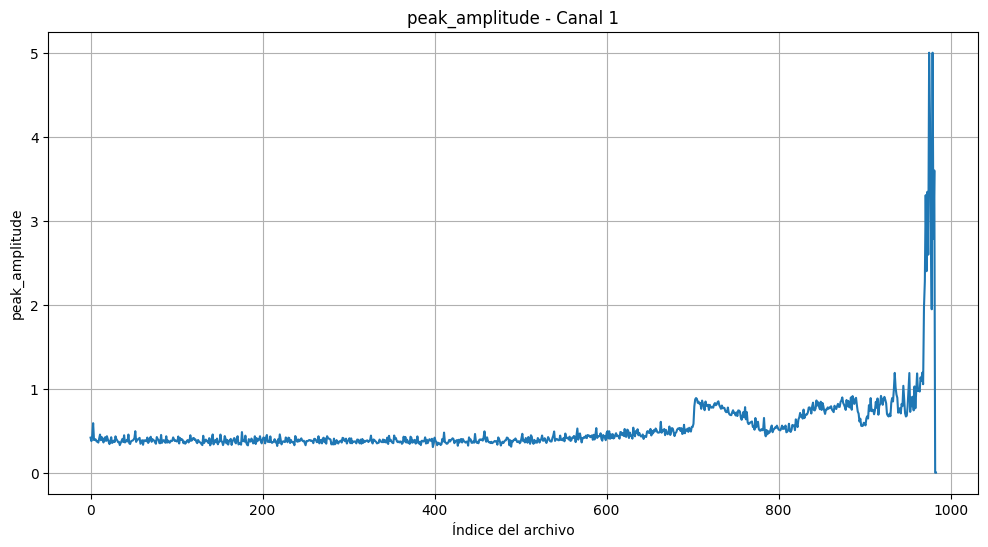

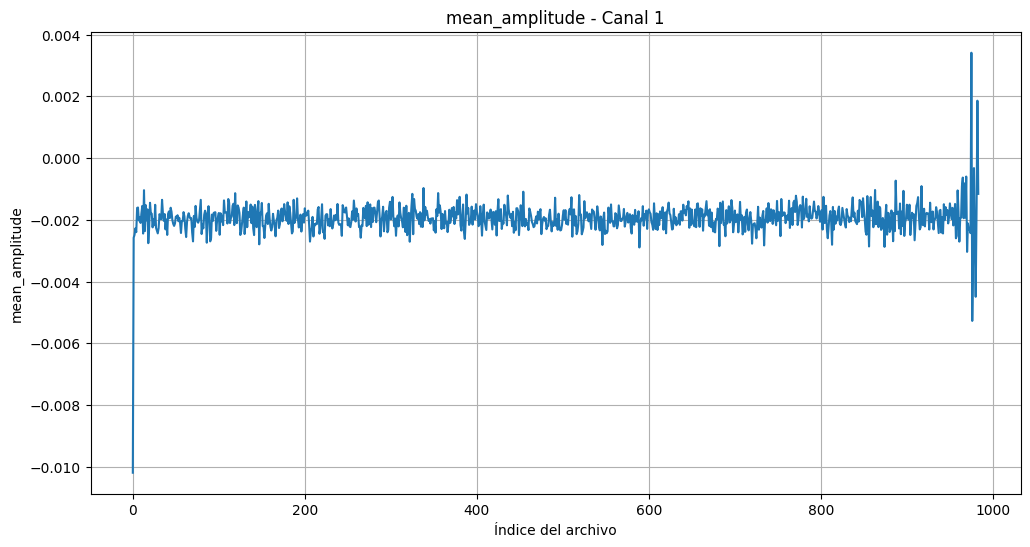

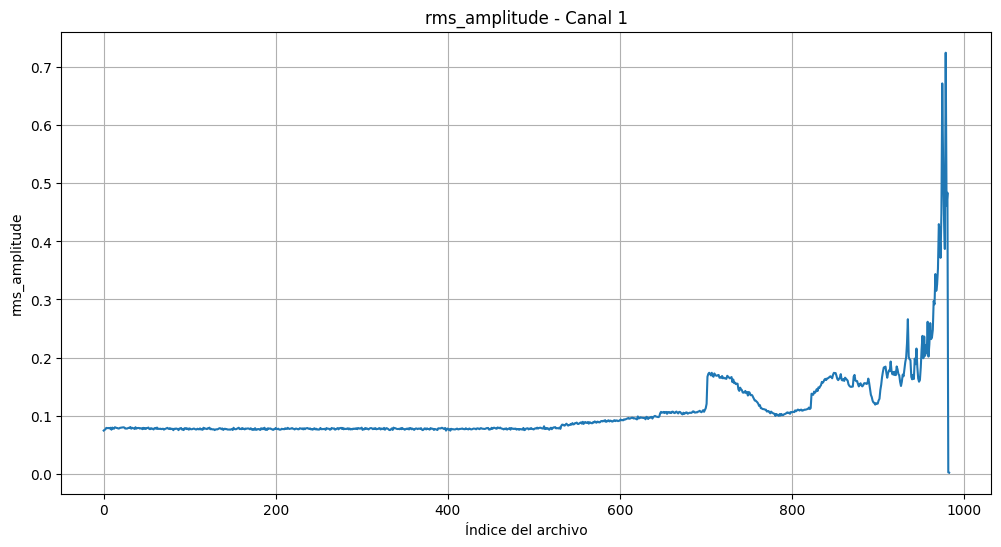

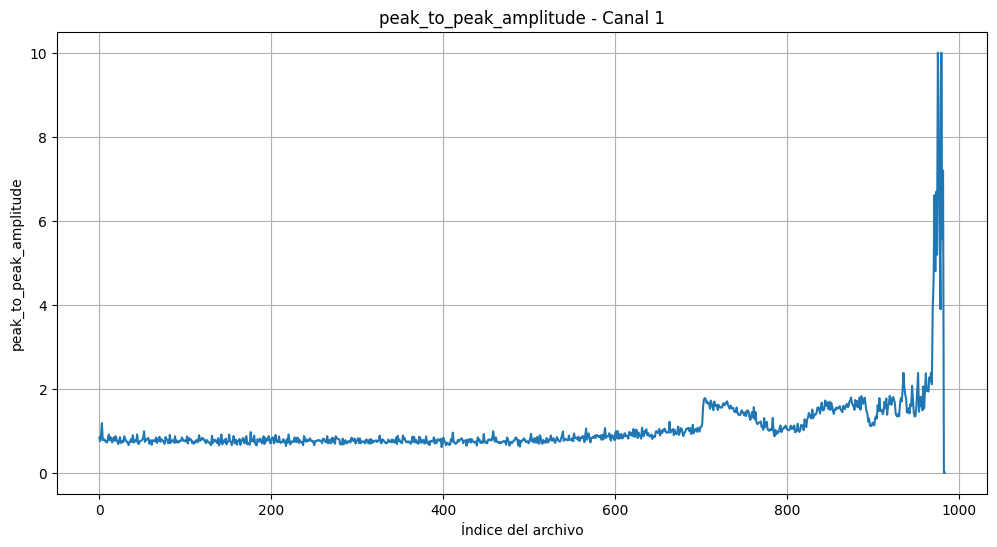

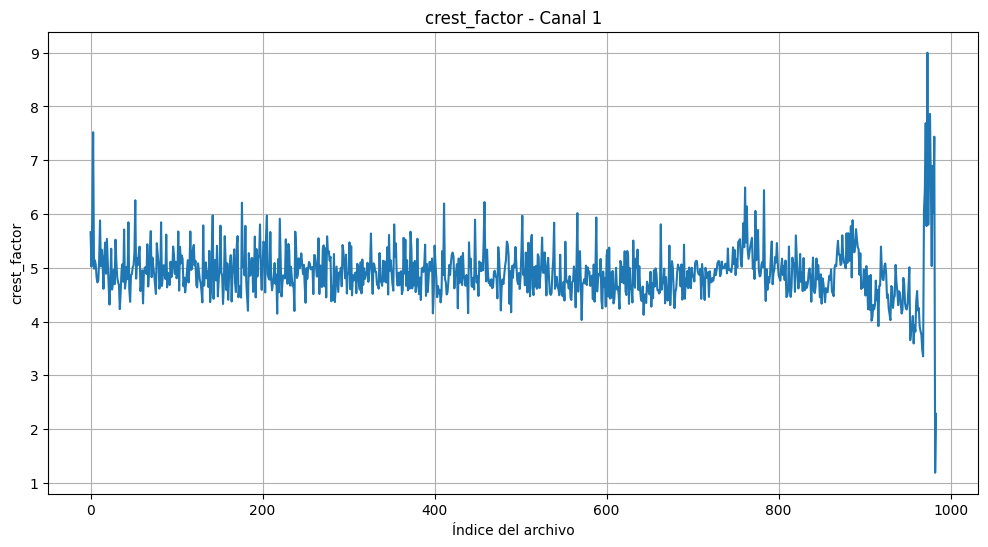

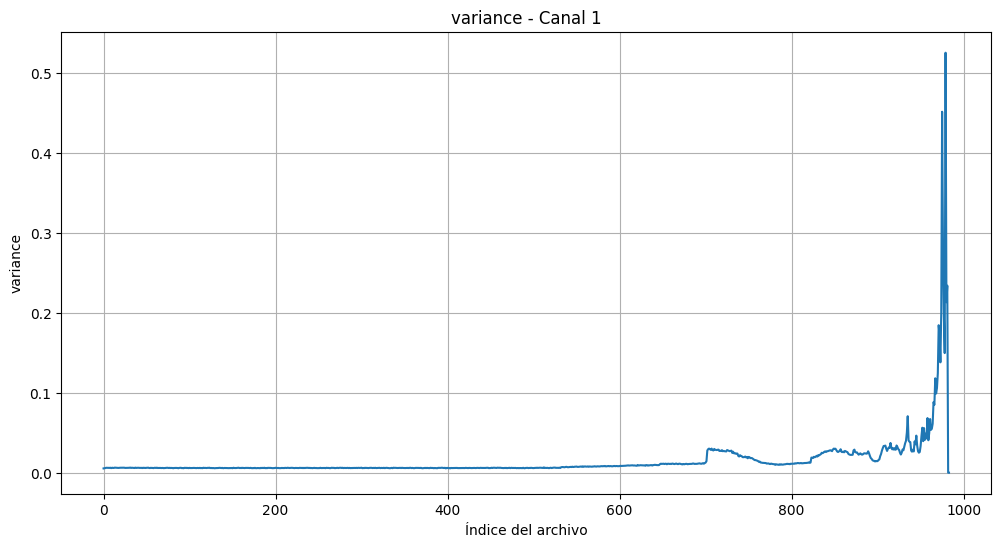

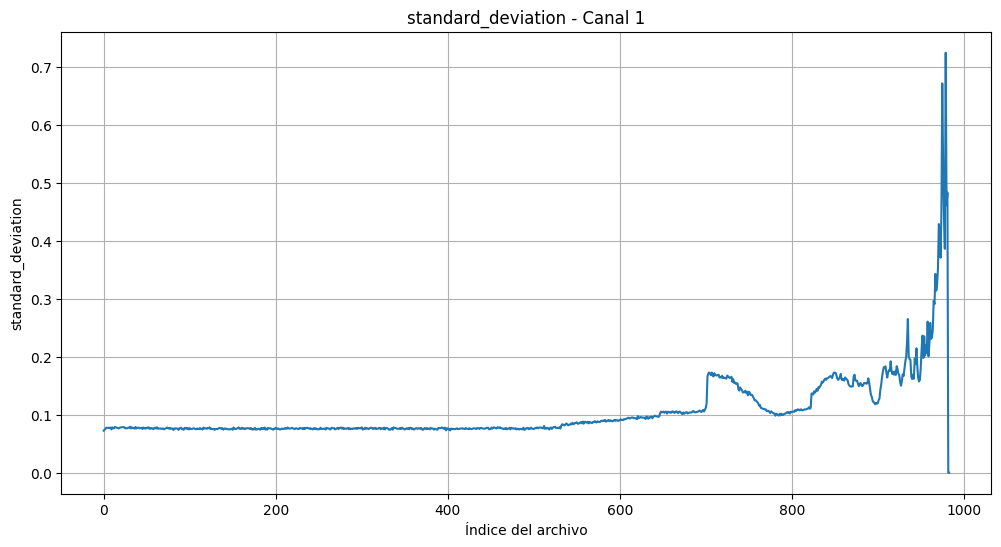

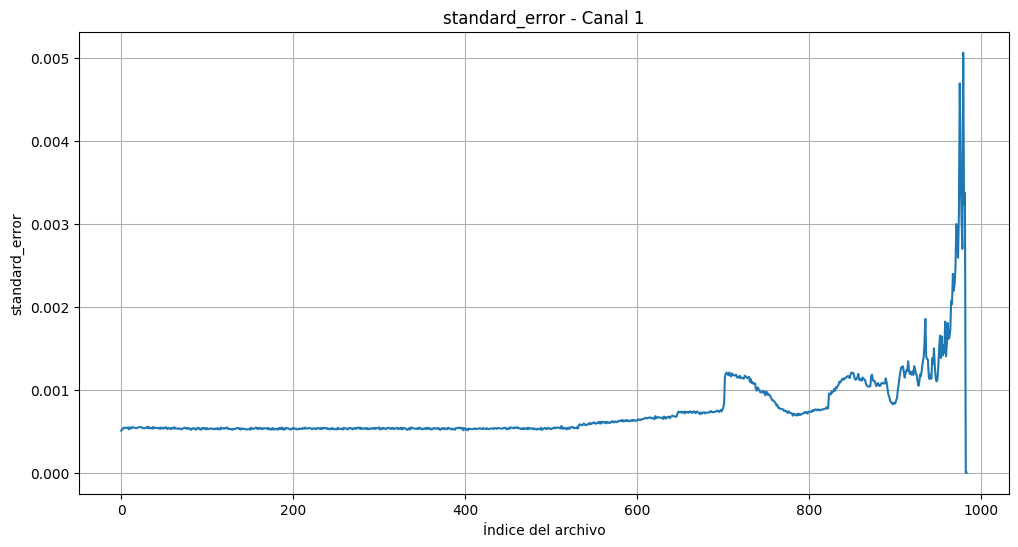

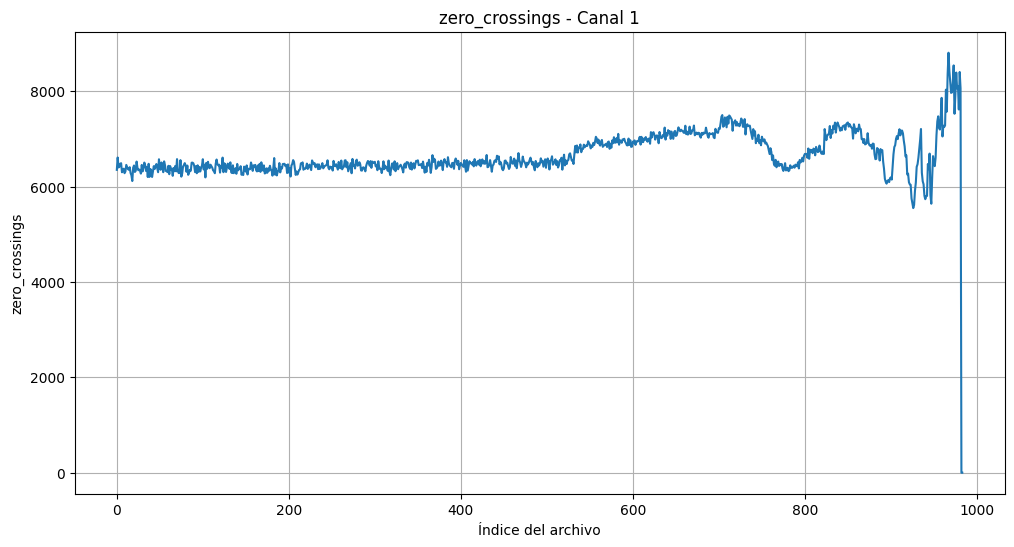

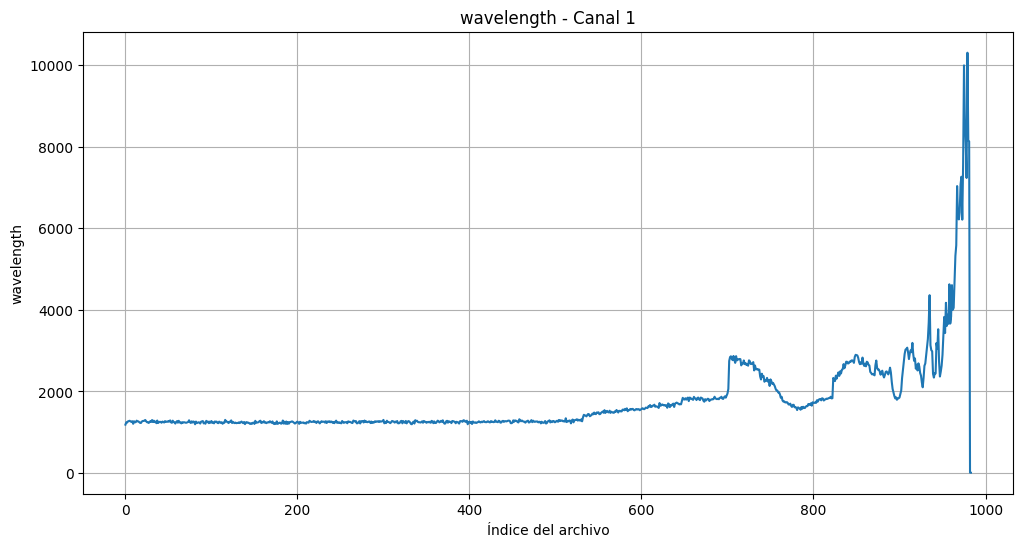

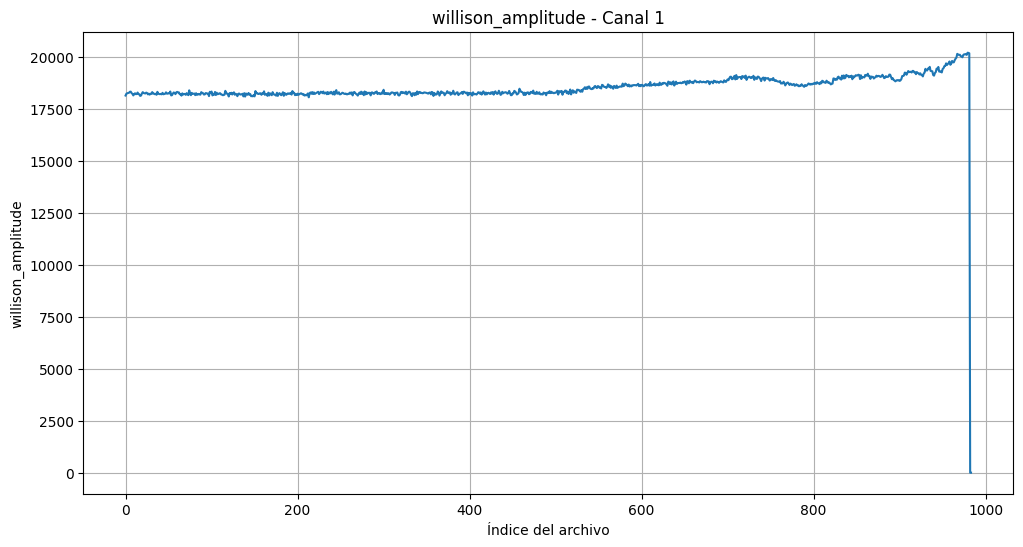

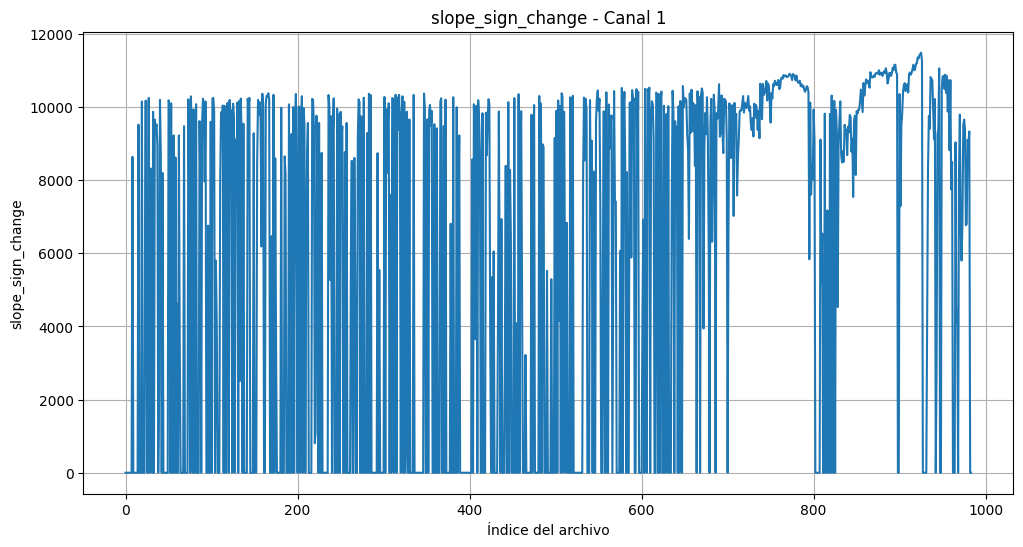

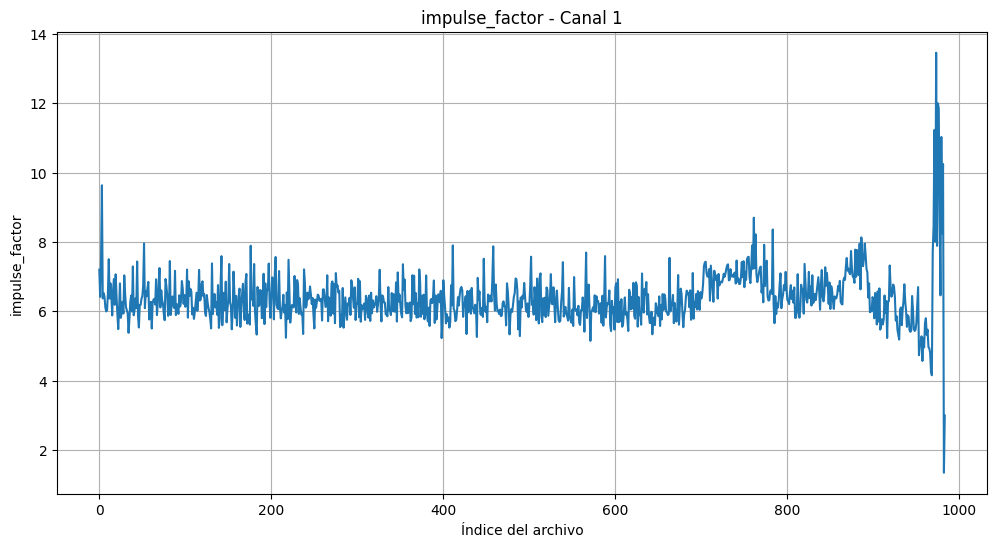

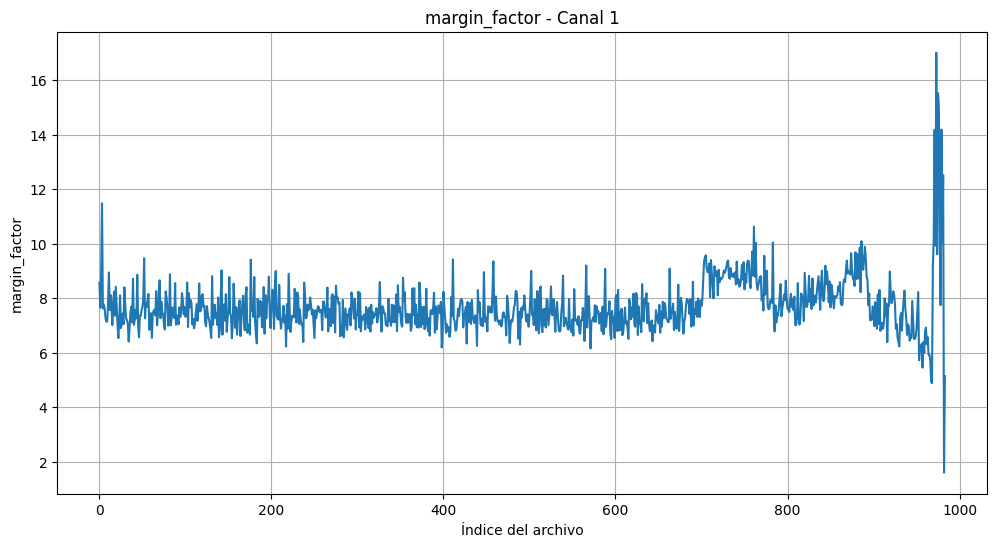

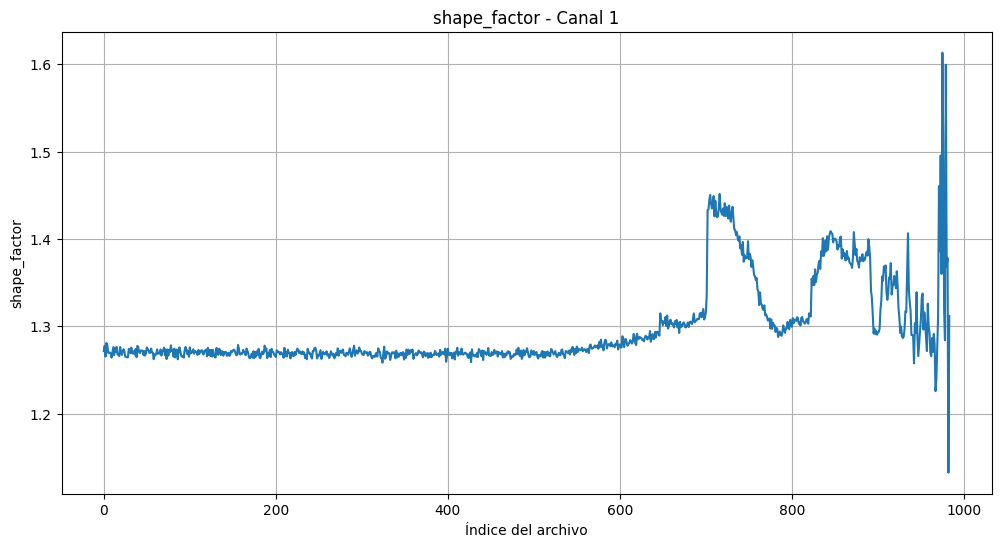

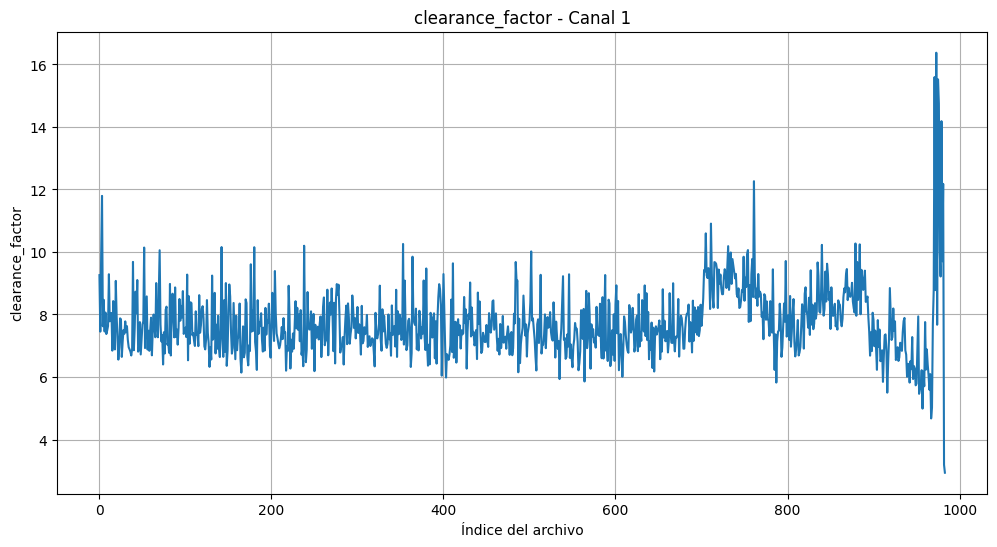

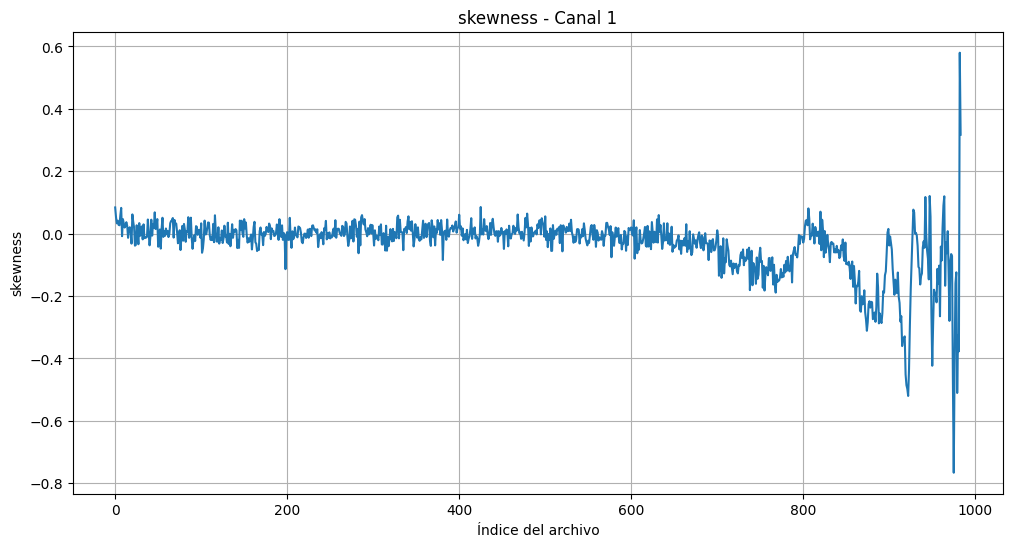

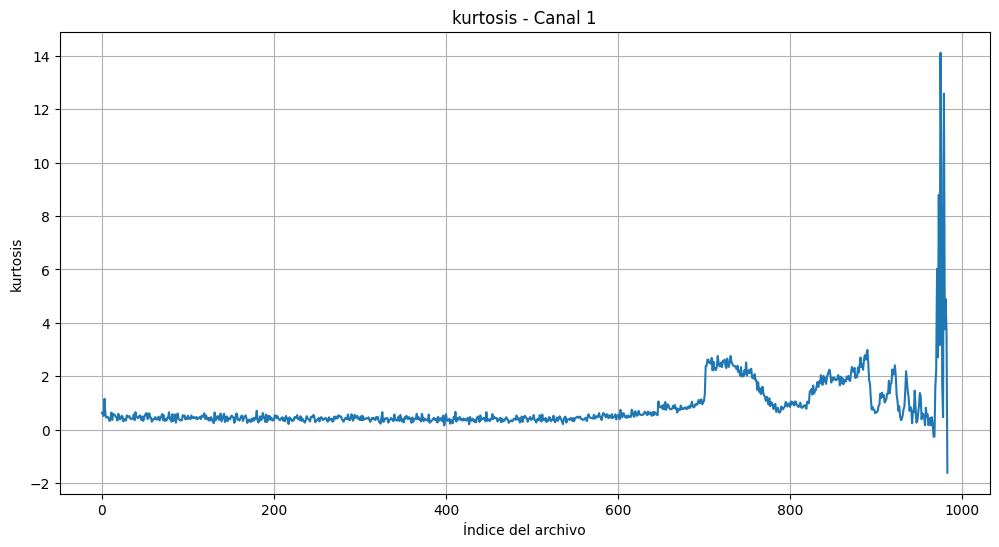

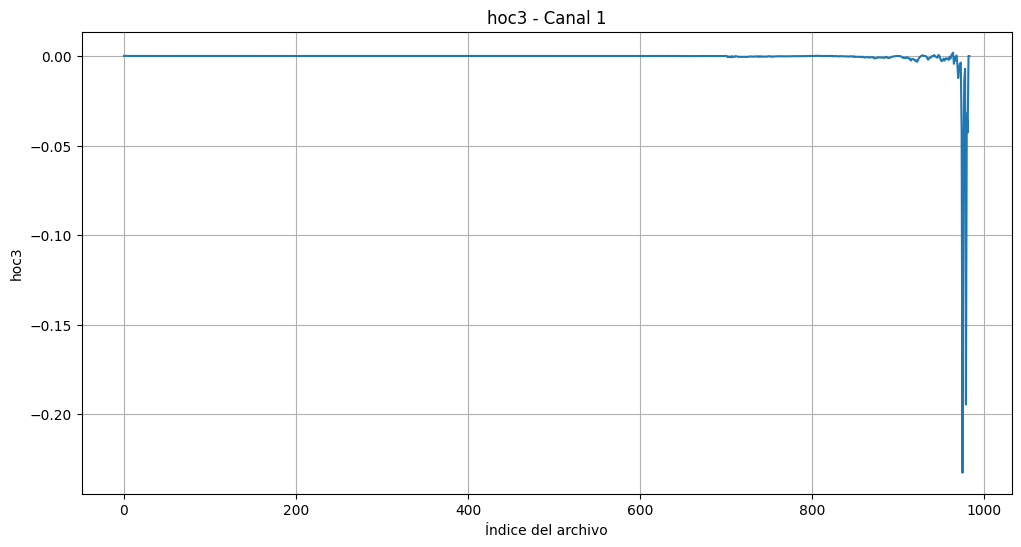

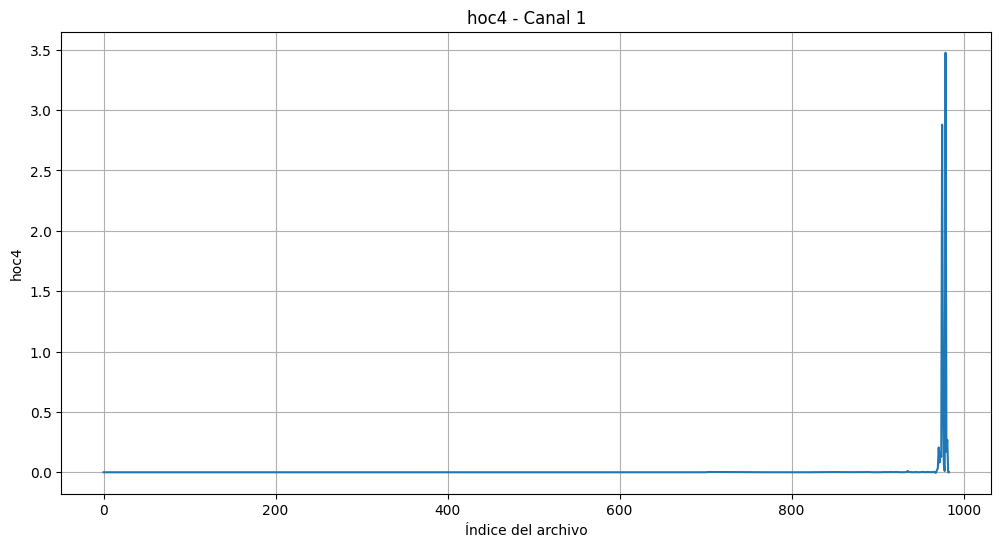

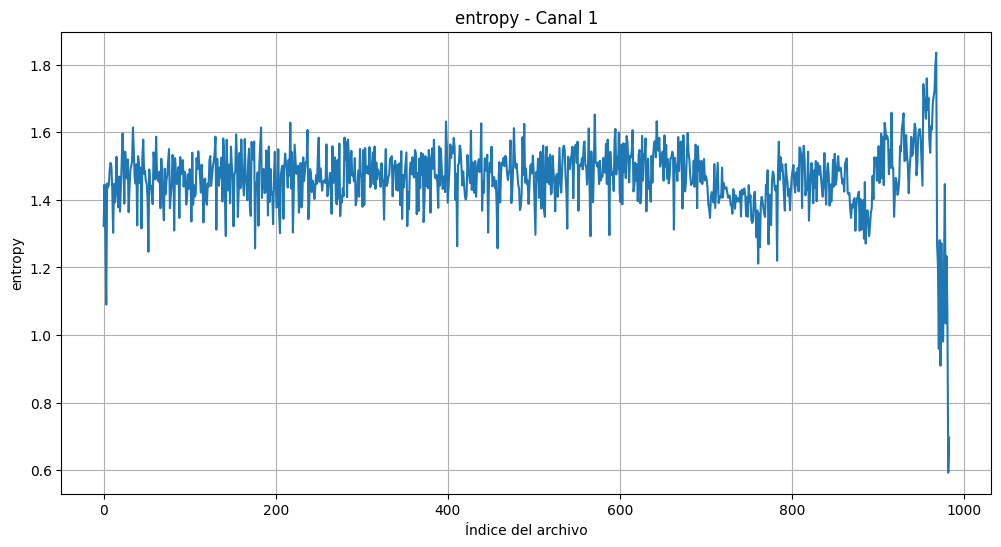

In [142]:
for i in range(len(estadisticas_a_graficar)):
    estadistica = estadisticas_a_graficar[i]
    mostrar_grafica(df_agregado_2nd_test, 'Canal 1', estadistica)

### Gráficas 1st_test (target: salud)

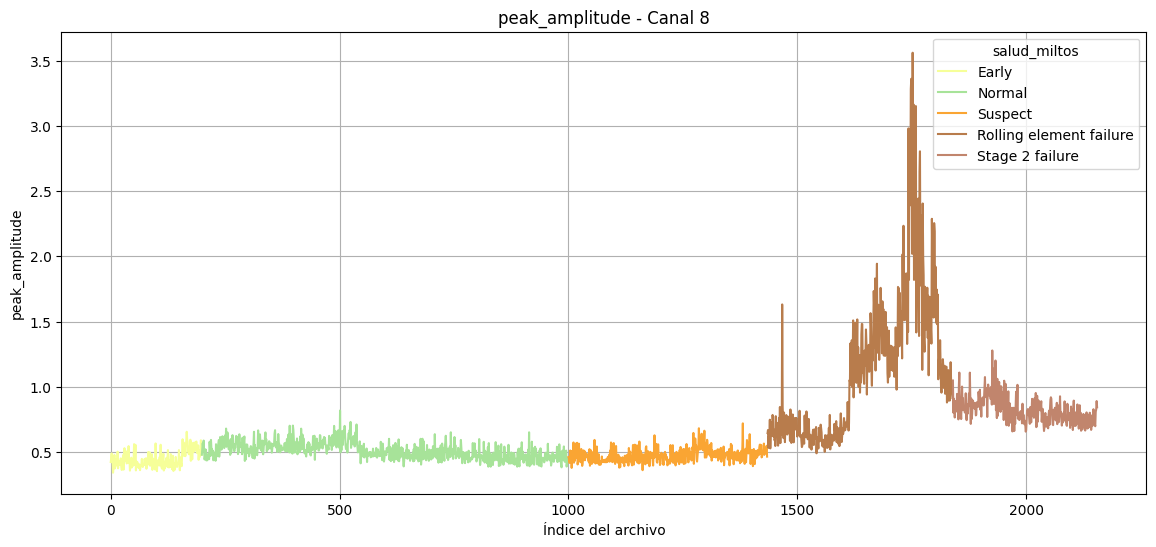

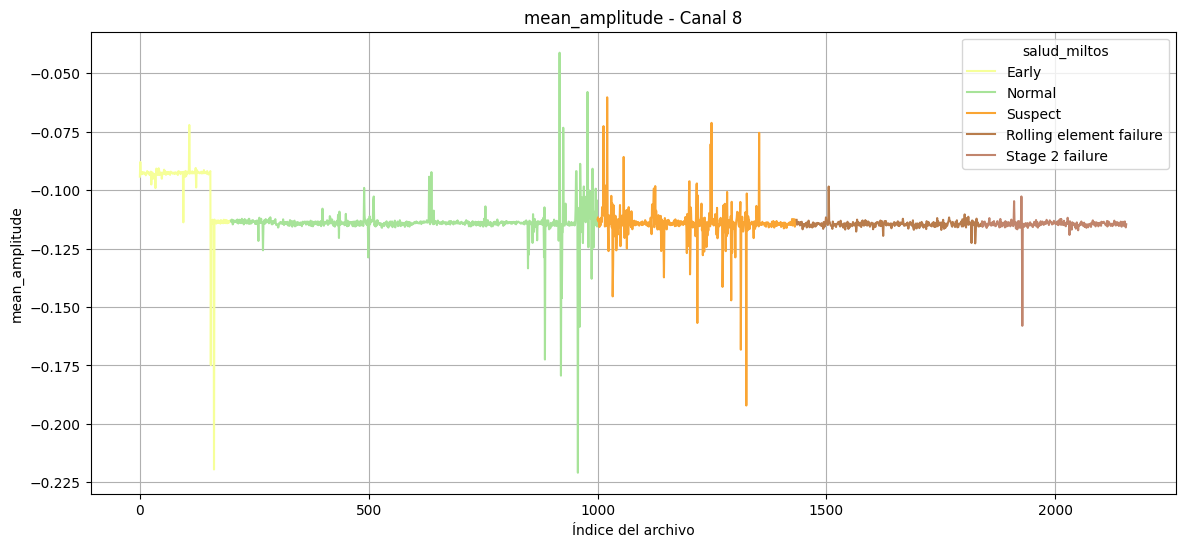

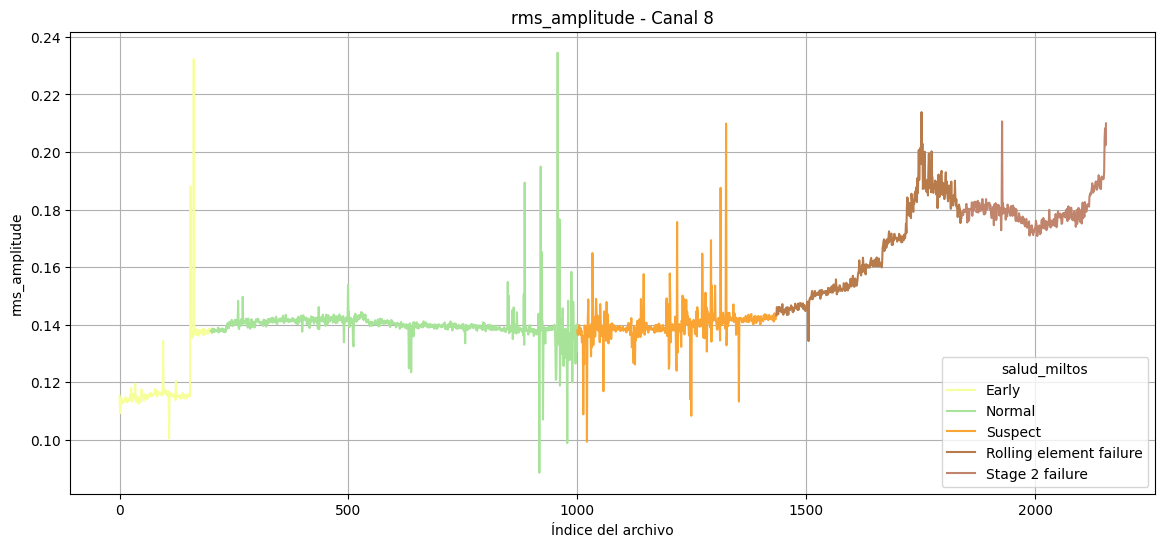

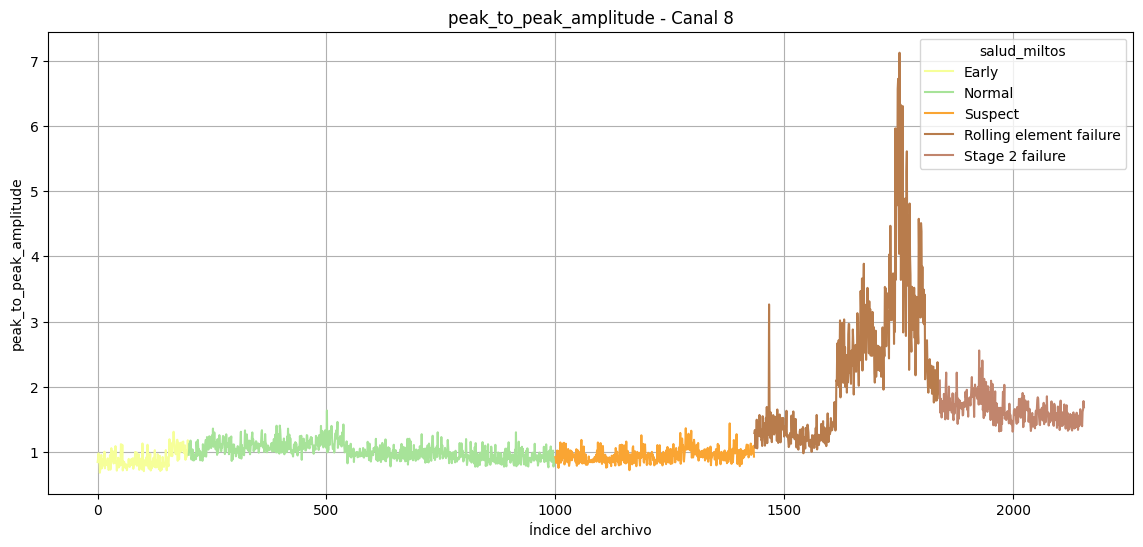

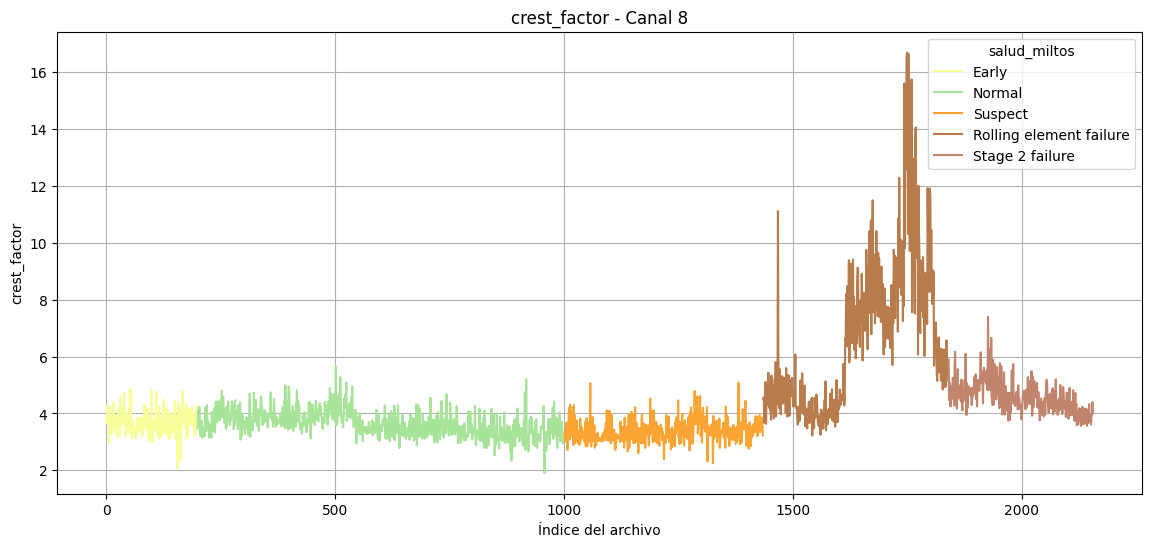

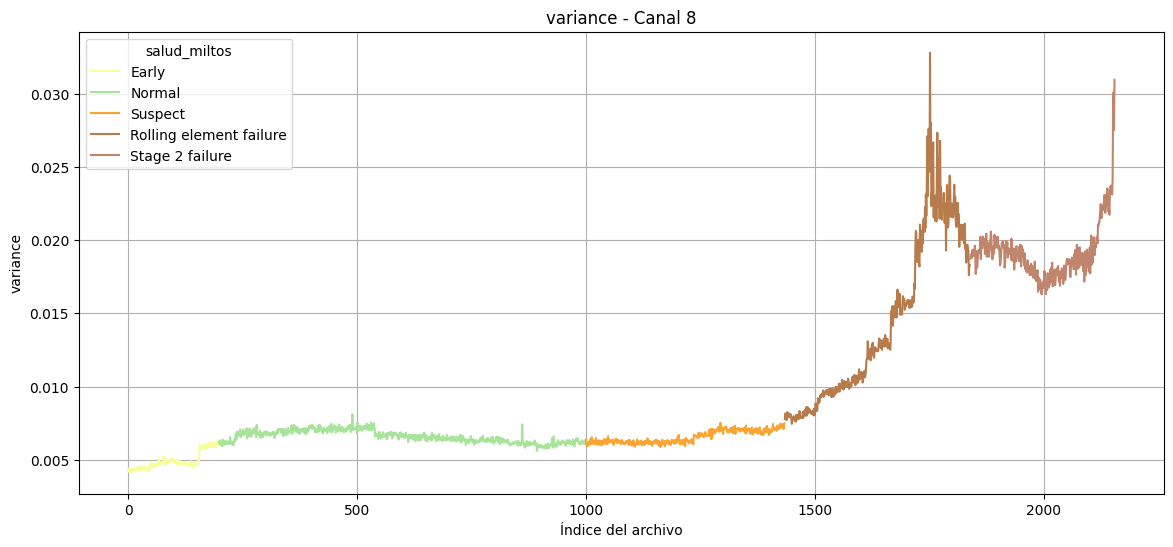

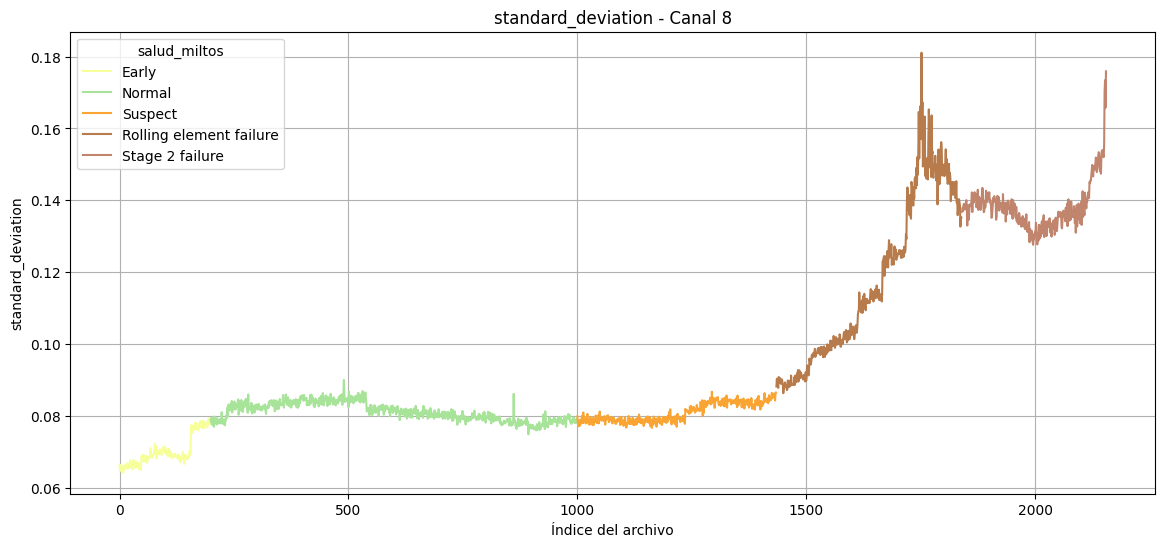

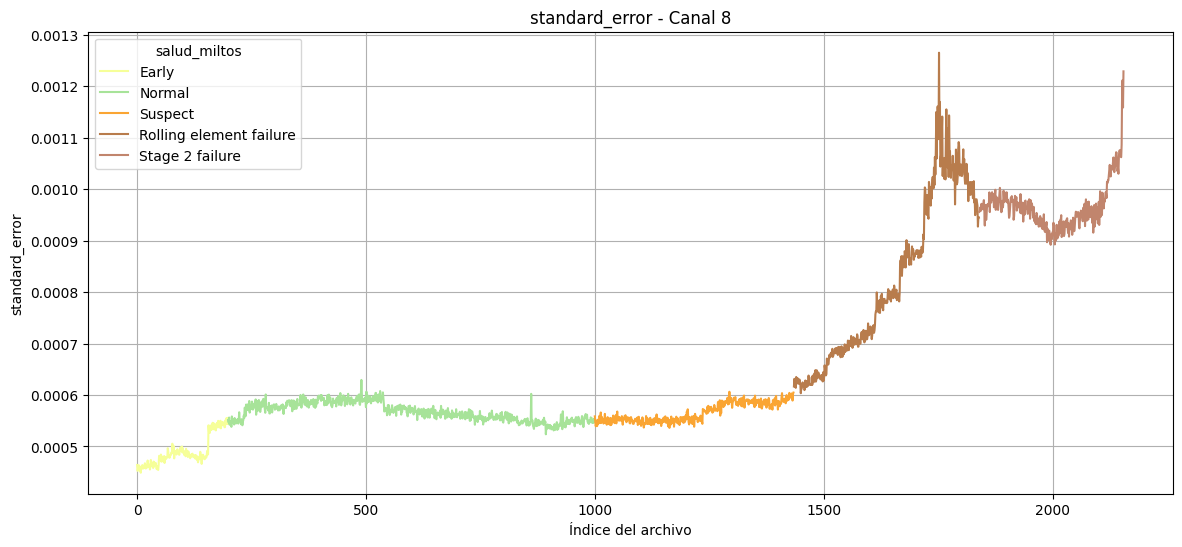

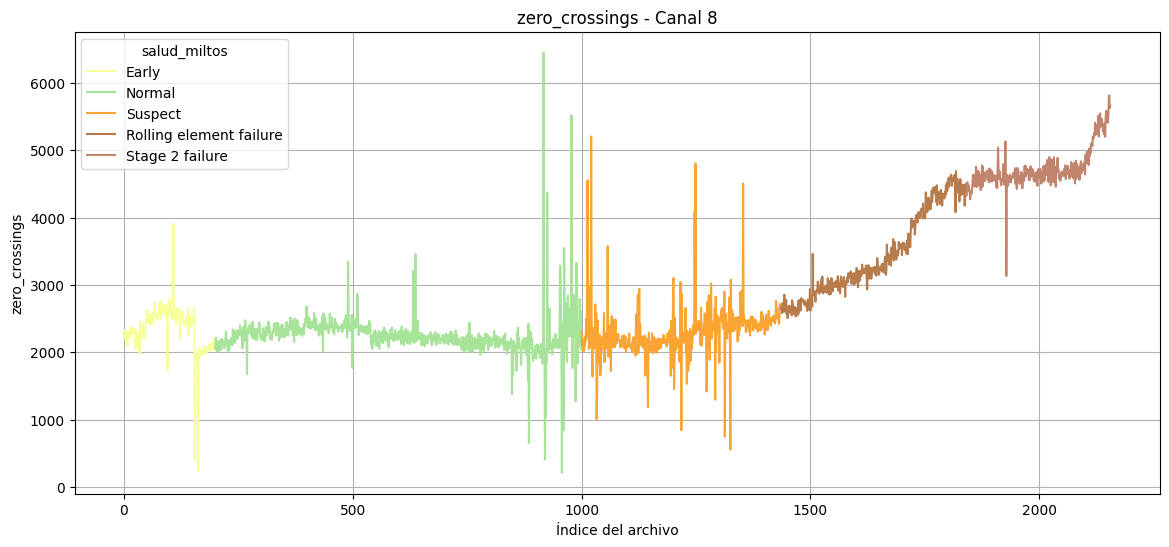

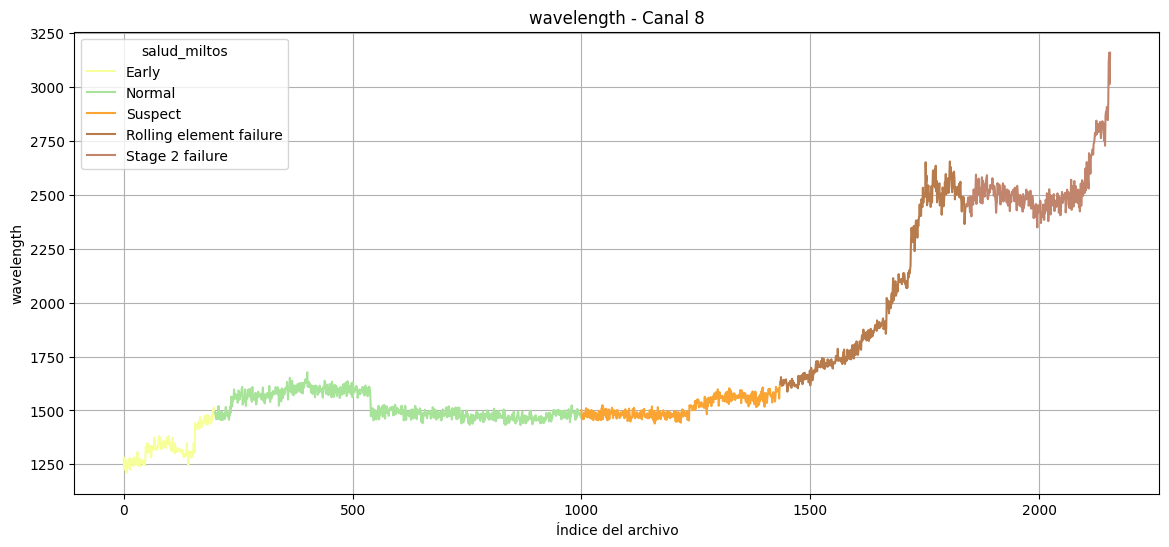

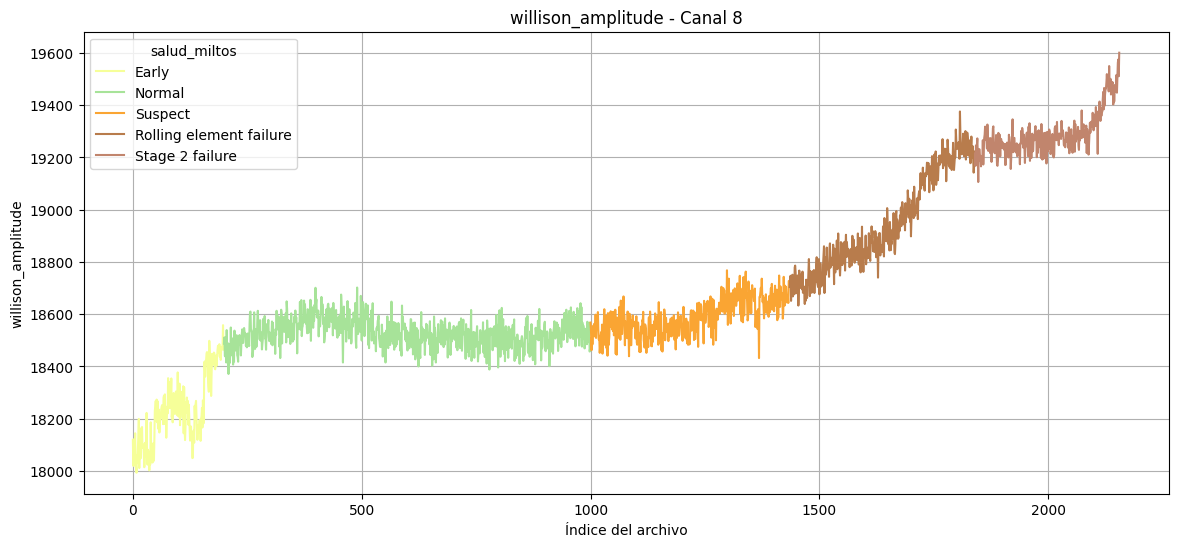

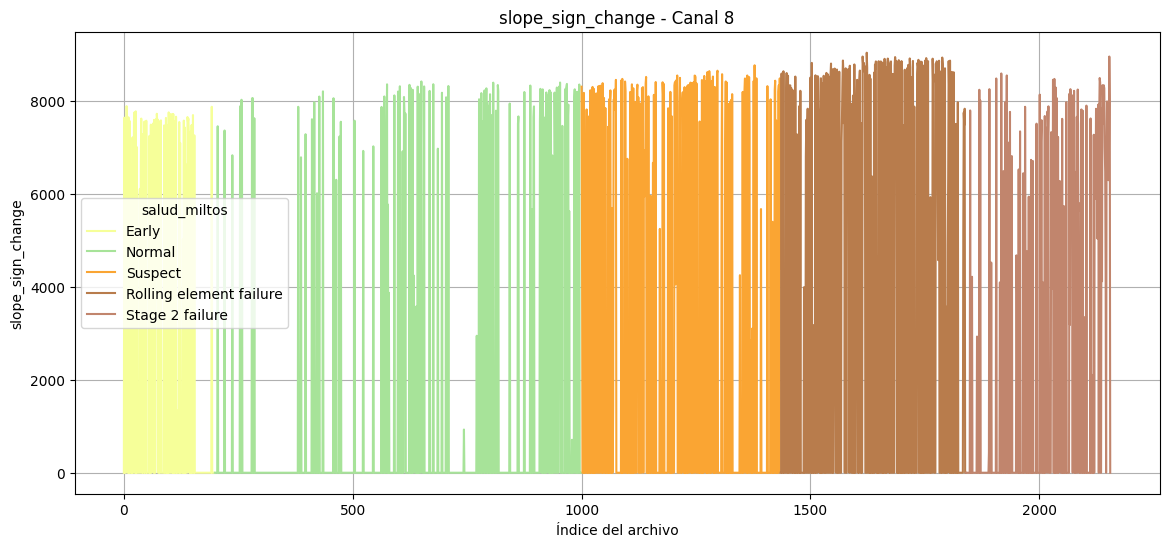

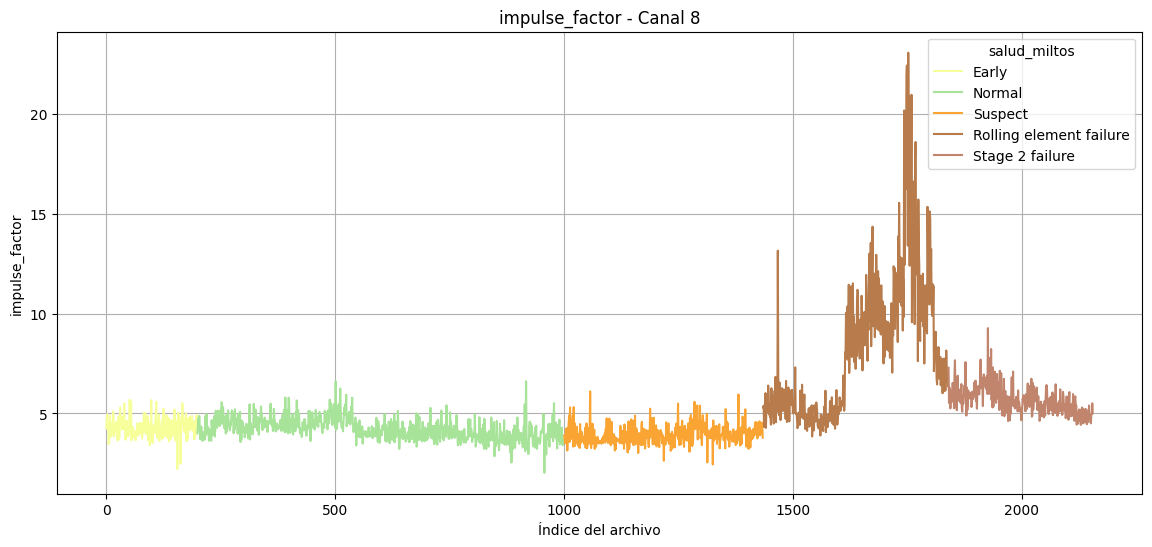

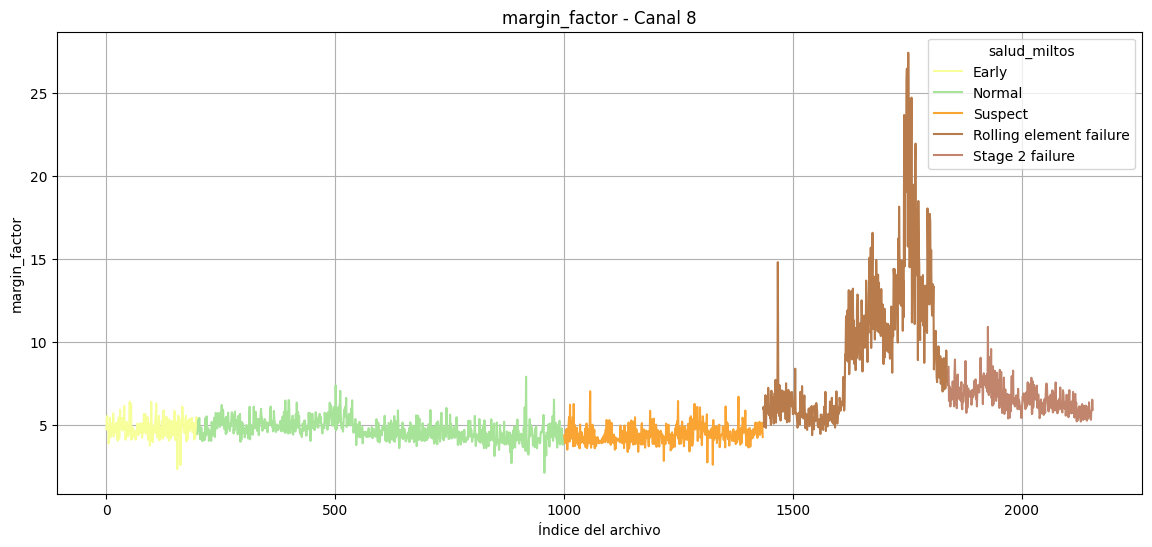

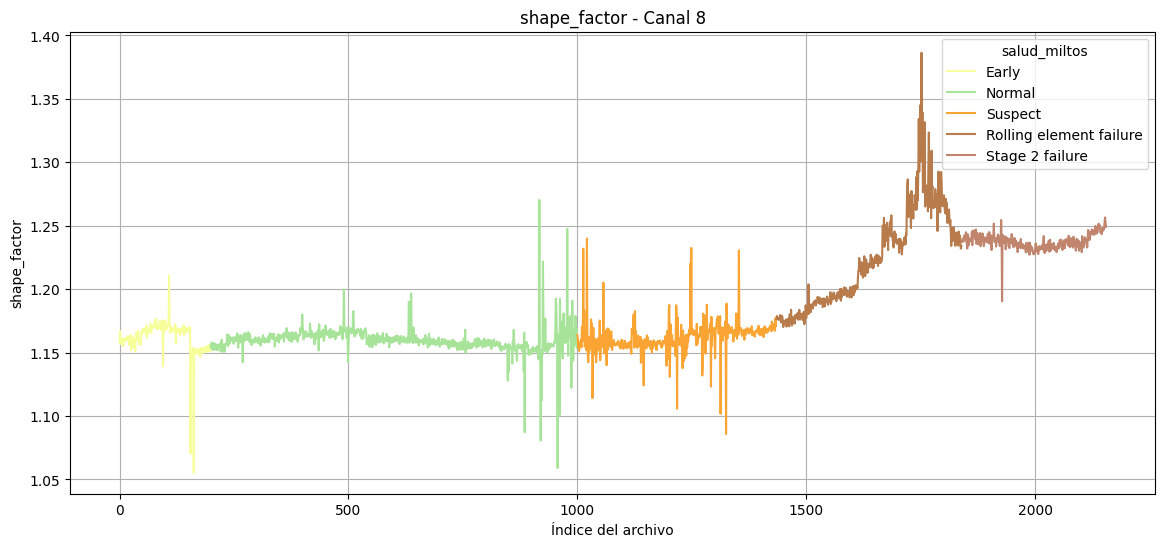

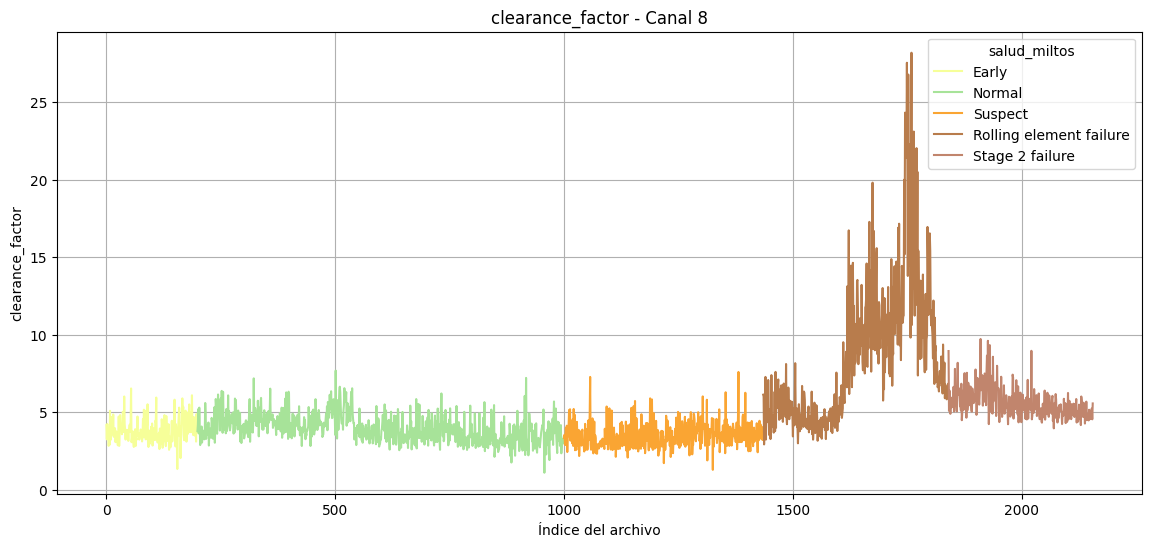

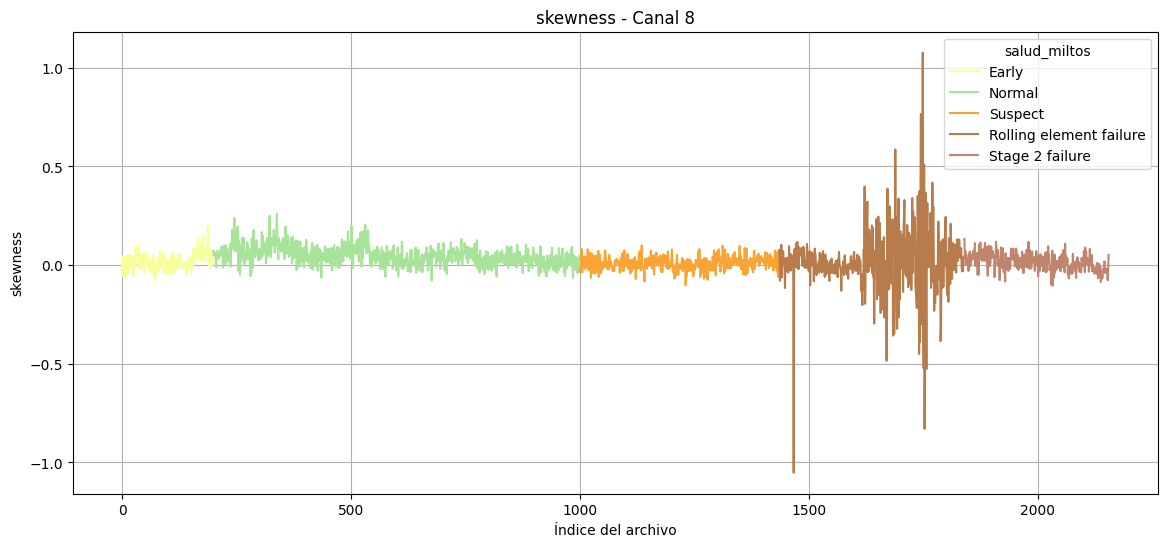

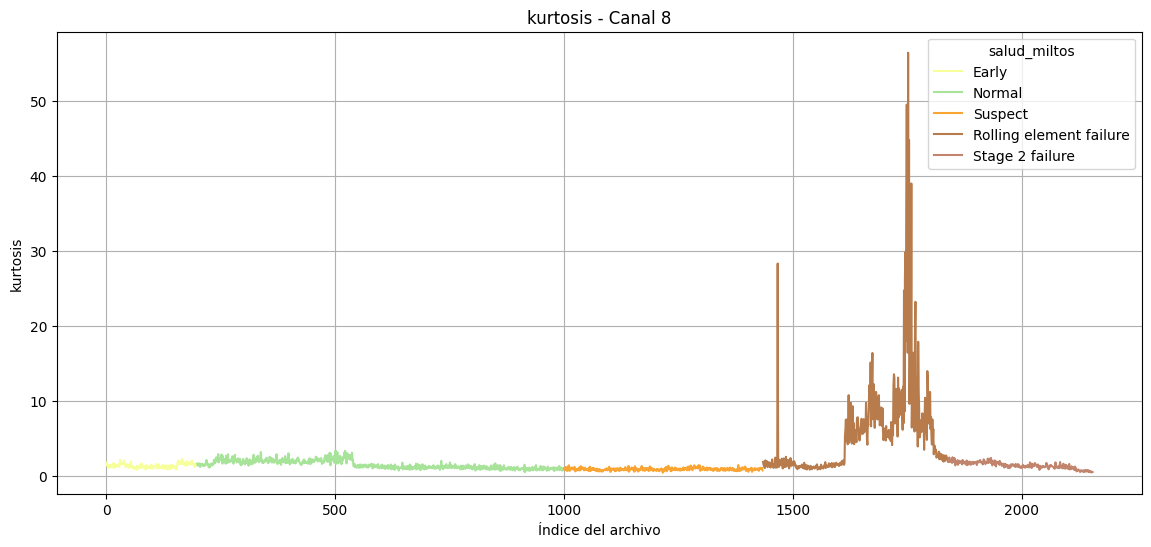

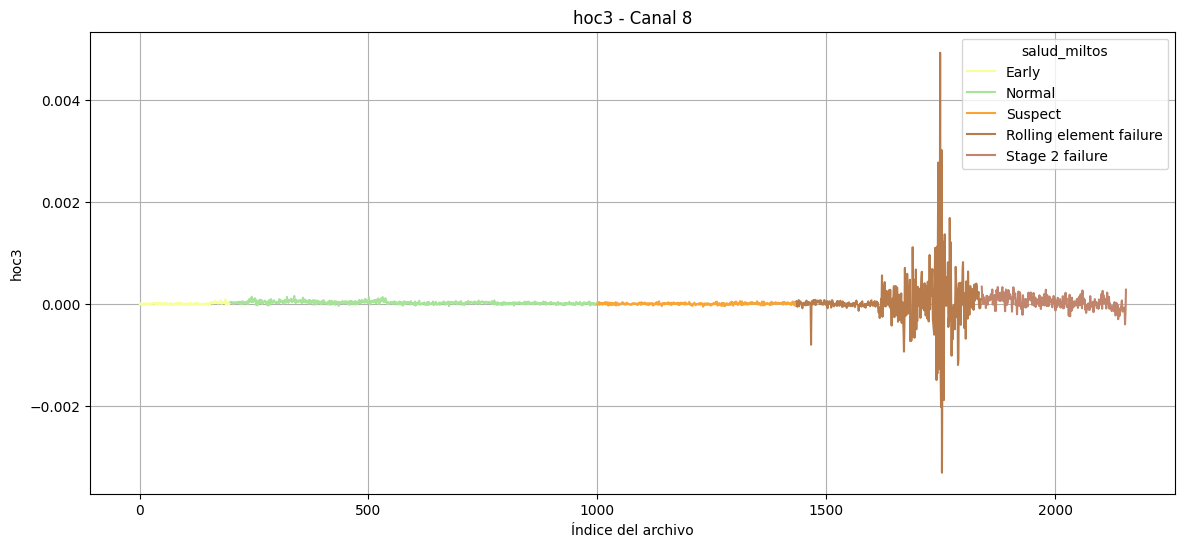

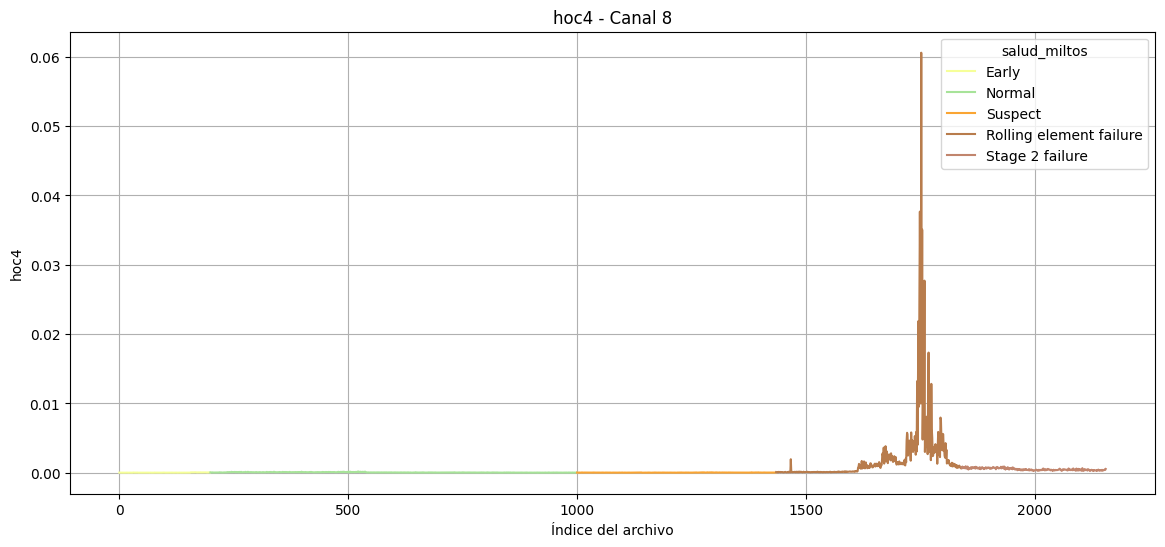

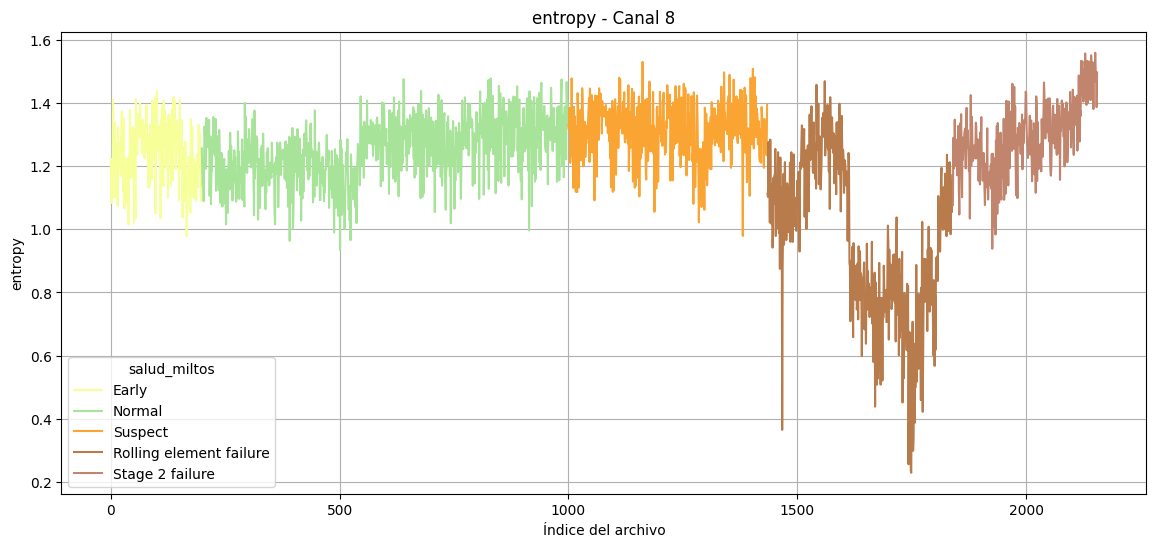

In [143]:
for i in range(len(estadisticas_a_graficar)):
    estadistica = estadisticas_a_graficar[i]
    mostrar_grafica_target(df_agregado_1st_test, 'Canal 8', estadistica, 'salud_miltos', colores_salud_hex)


**Análisis**

Los estadísticos revelan tendencias que eran difíciles de ver con los datos crudos. Por ejemplo, en el rodamiento 1 del experimento 1st_test se sabía por el análisis de Miltos-90 que este rodamiento presentó una falla al inicio del experimento y que se disipó con el transcurso del tiempo. Los estadísticos mean, rms_amplitude, crest_factor, variance, standard_deviation, standard_error, wavelength, Willison_amplitude, impulse_factor, margin_factor, shape_factor y entropy revelan entre los primeros quintiles un cambio brusco de las magnitudes mostrando la certeza de Miltos-90. 


Al observar los gráficos de los canales correspondientes a los rodamientos 1 y 2 (canales 1, 2, 3 y 4) se observa que algunos estadísticos reflejan un cambio abrupto a final de los experimentos lo que en un principio puede interpretarse como la presencia de una falla o deterioro en el rodamiento. Sin embargo estos rodamientos no fueron marcados con fallas al final del experimento. Esto sugiere que los rodamientos presentaron algun tipo de deterioro que no fue descrito en las fichas de los conjuntos de datos. También pudo ocurrir una distribución de la señal provocada por las fallas en los rodamientos 3 y 4. 

El estadístico slope_sign_change, que corresponde a cuantas veces se cambia el signo, presenta valores muy dispersos. Para este análisis se uso la curtosis como parámetro del estadístico.

Los rangos de salud propuestos por Miltos-90, que originalmente clasifican las series de tiempo crudas, guardan una relación adecuada con los estadisticos que obtuvimos de los datos crudos, por lo que se pueden considerar como una buena variable objetivo. 

### Gráficas 3rd_test (target: vida útil)

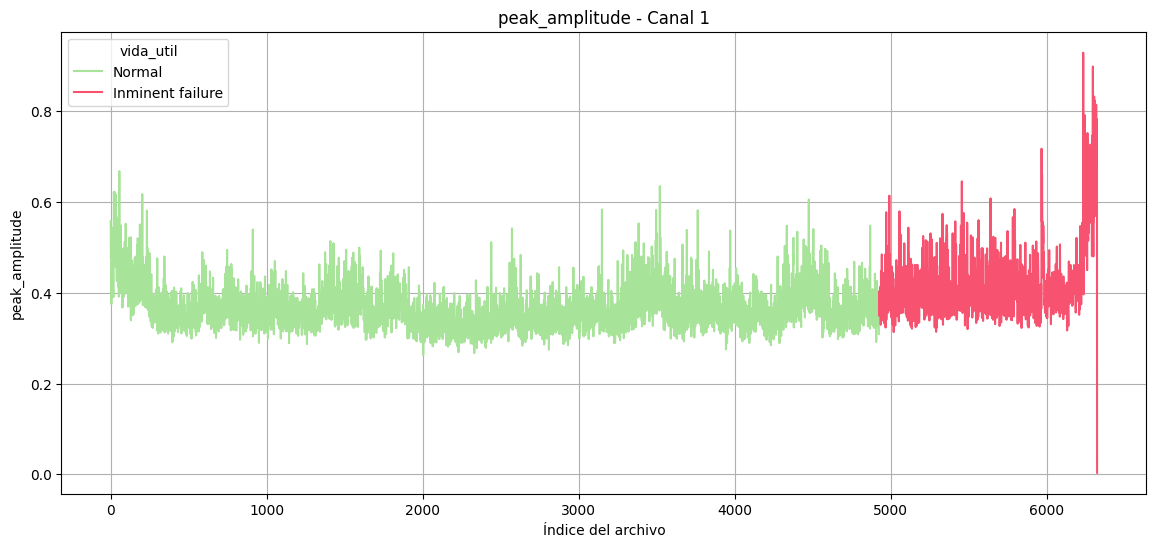

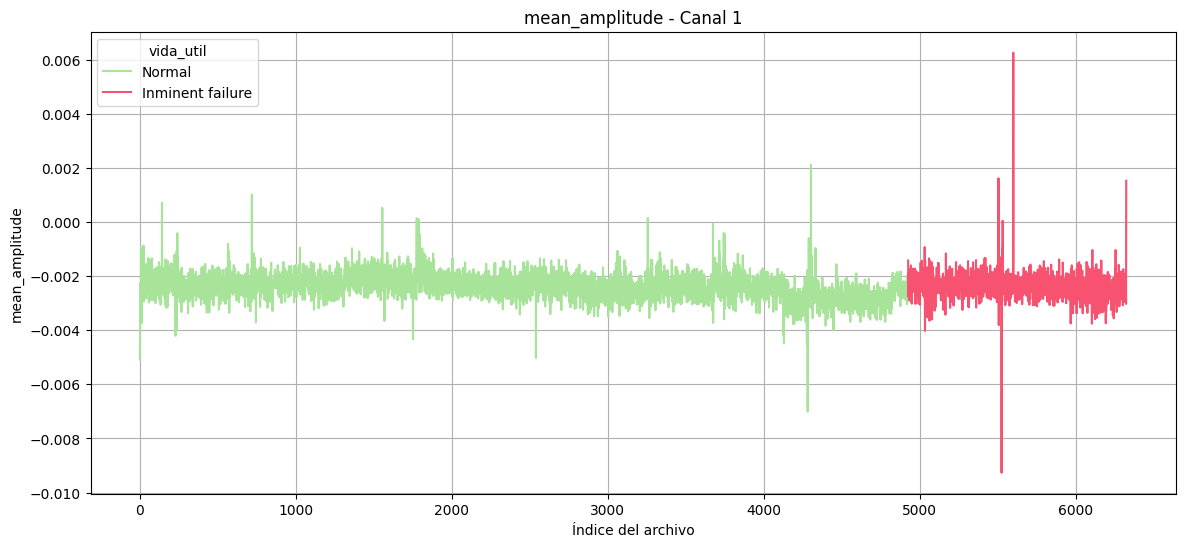

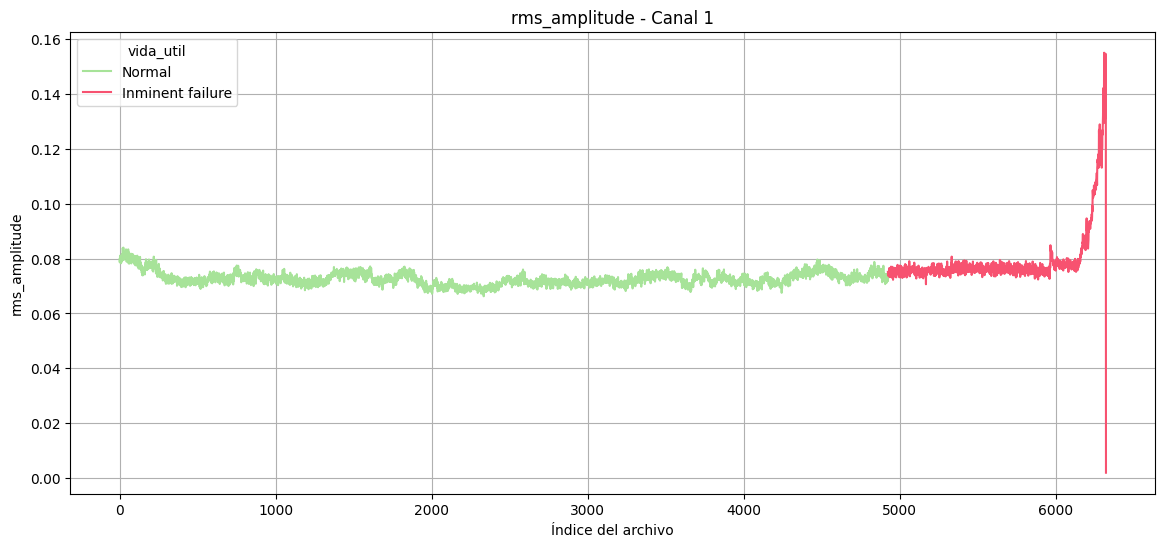

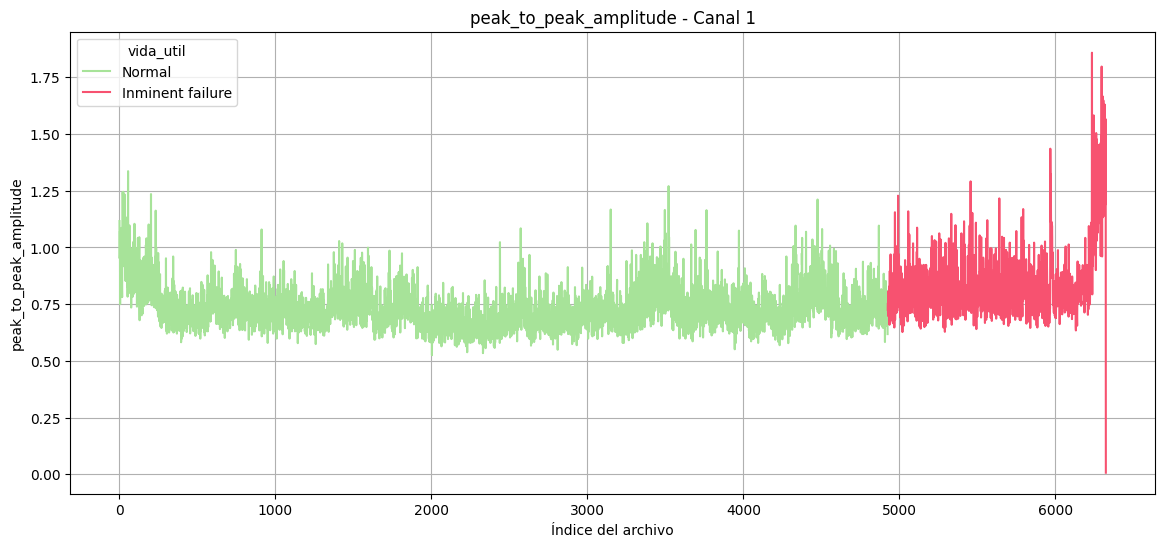

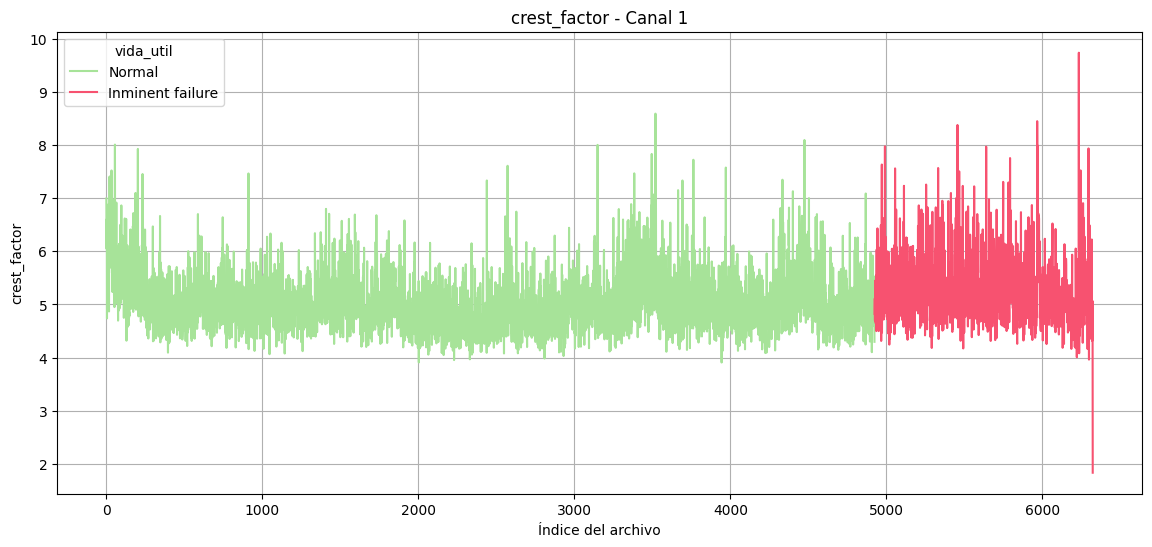

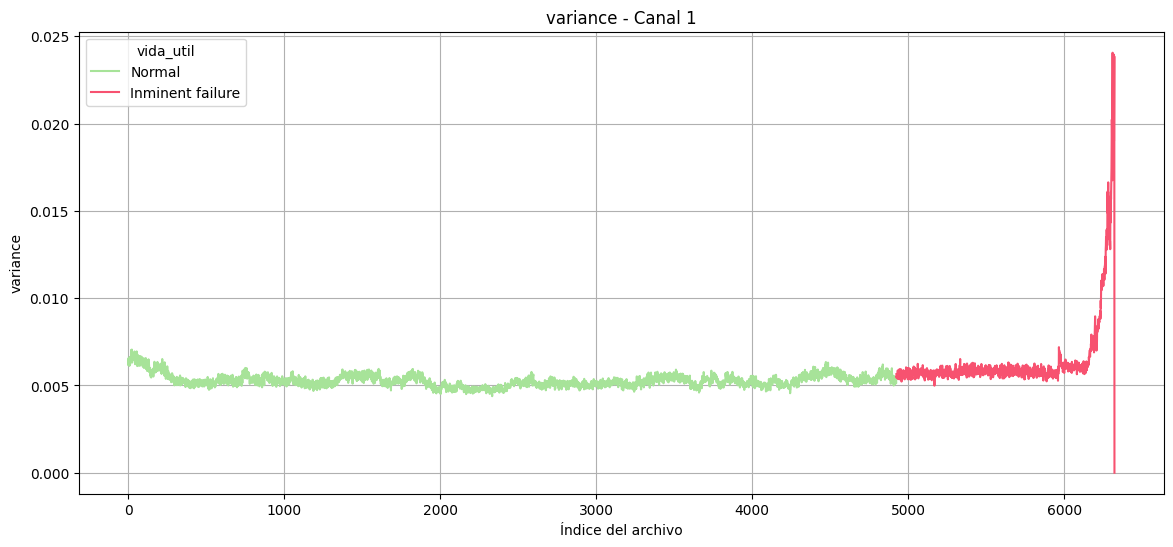

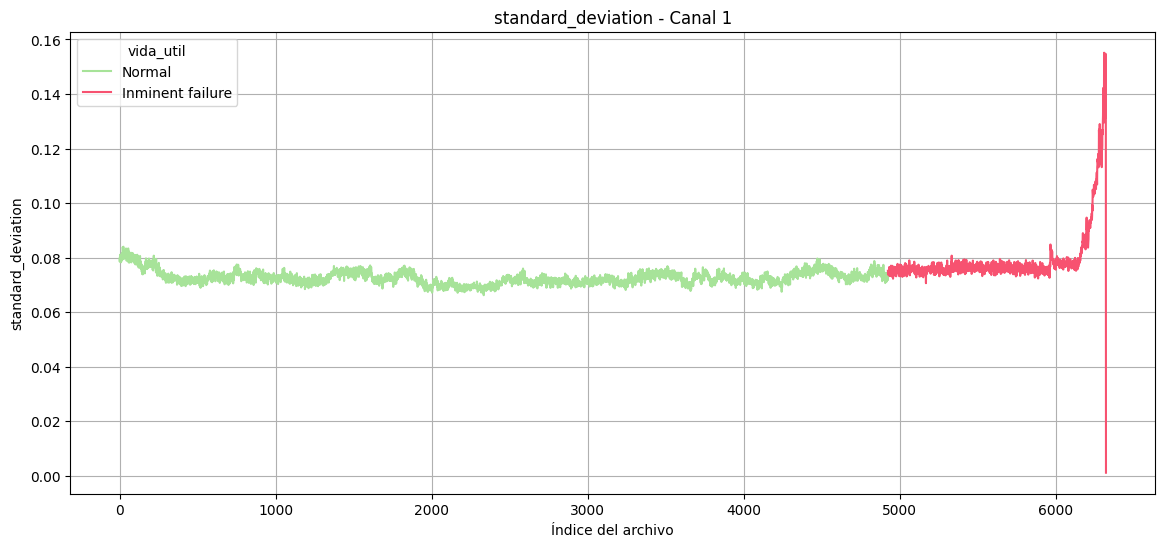

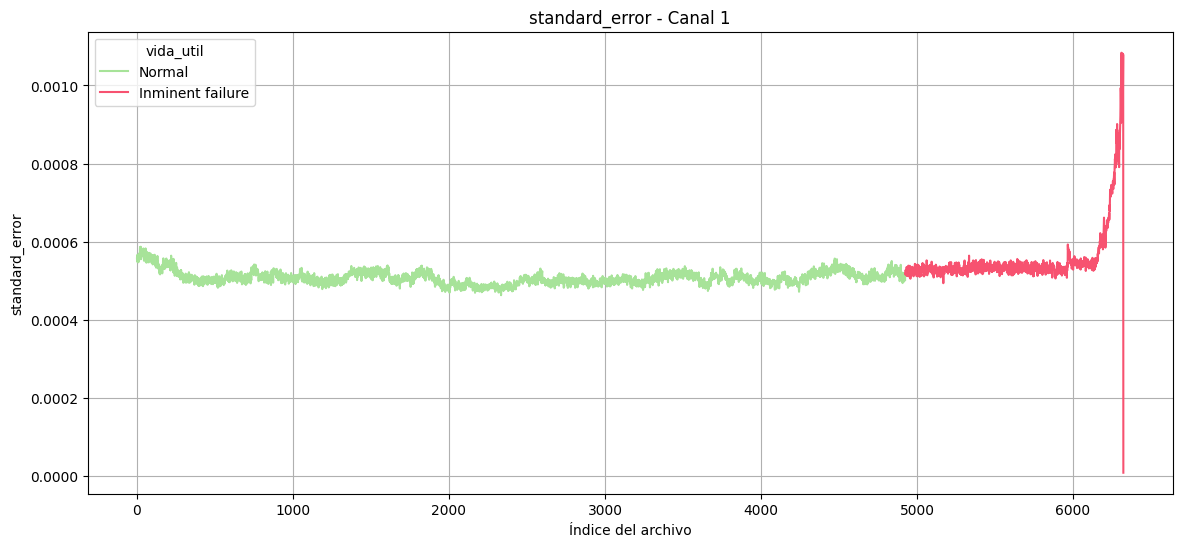

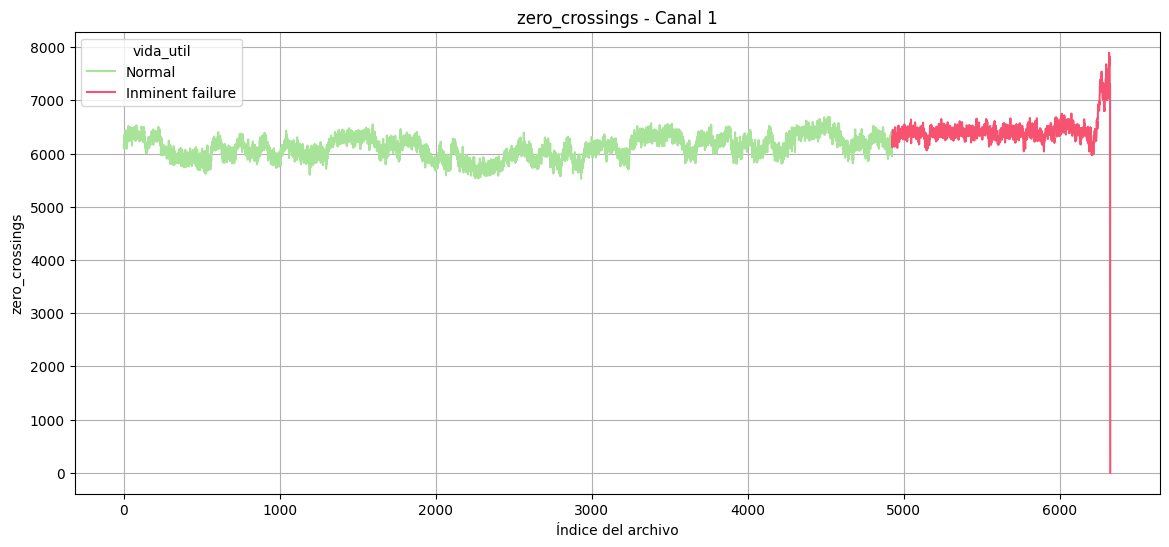

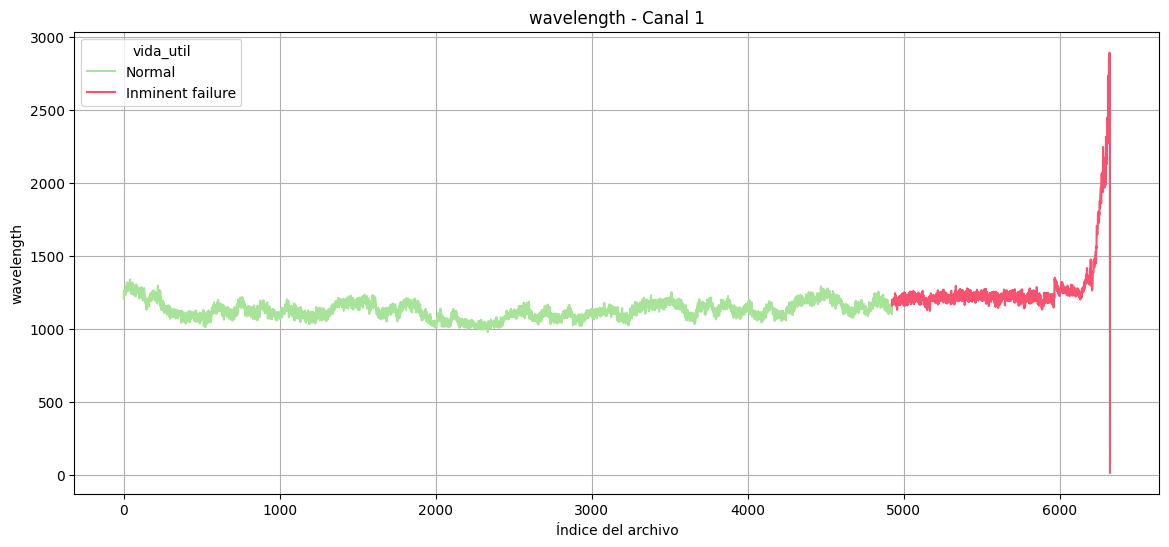

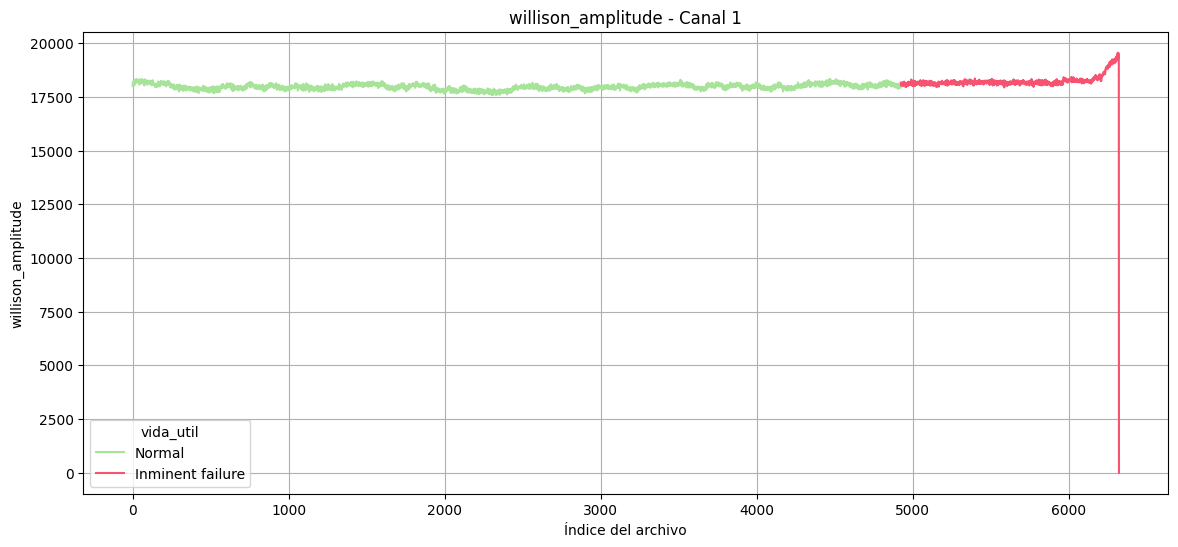

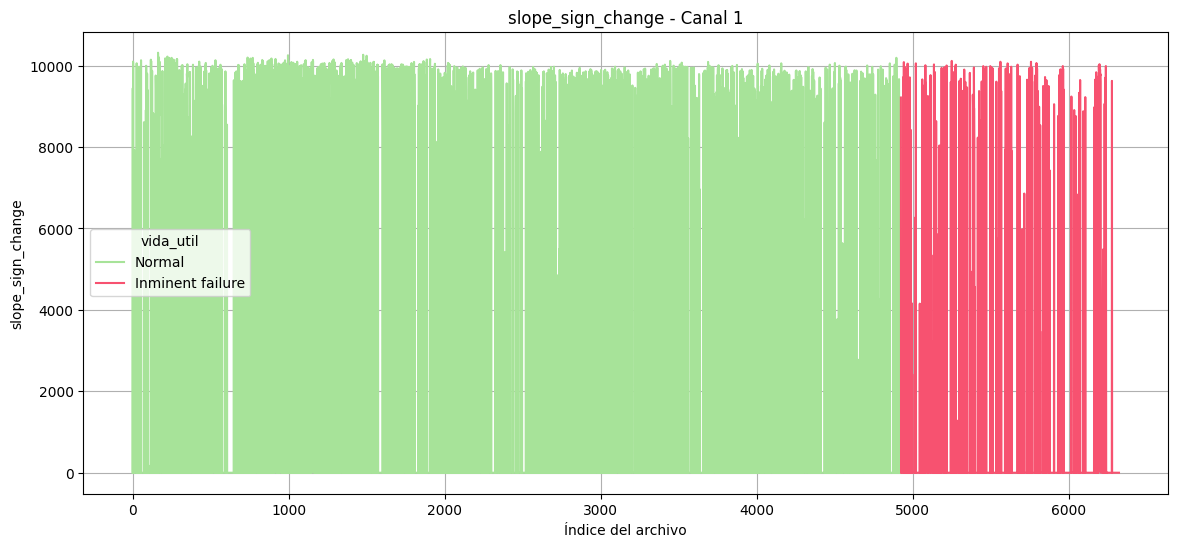

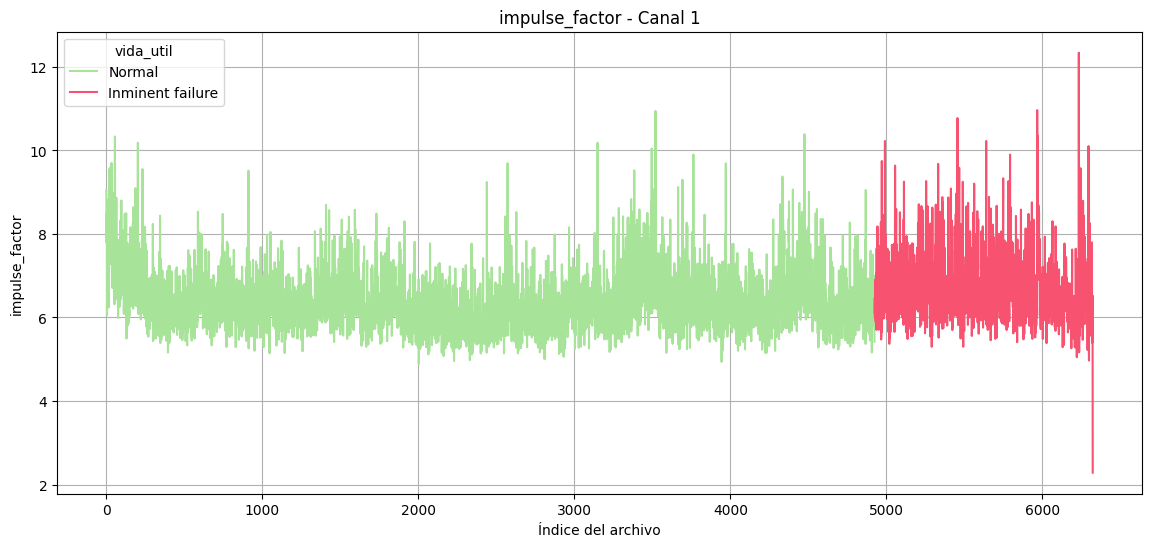

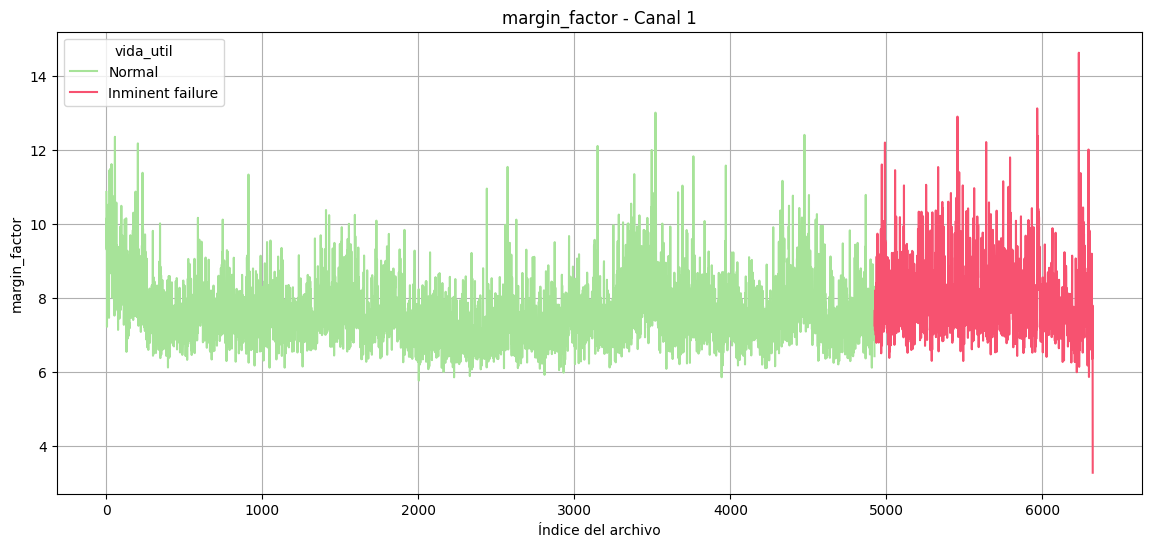

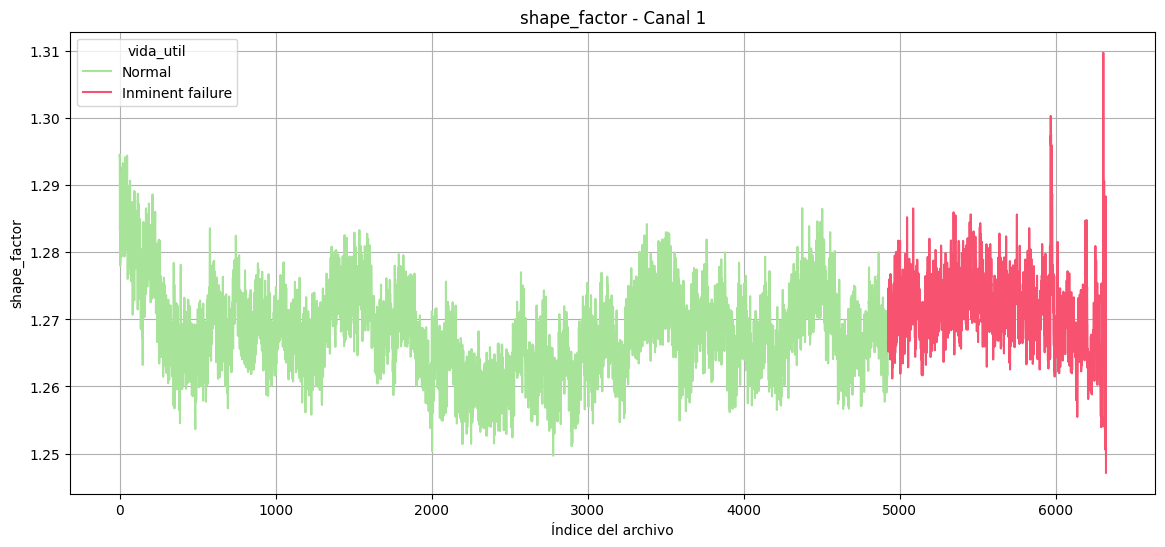

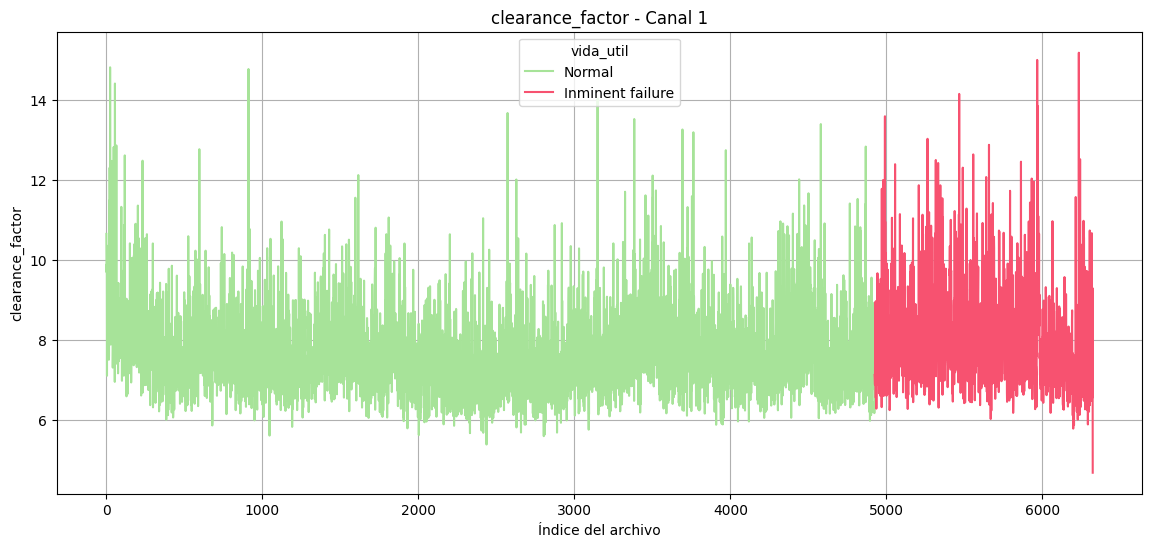

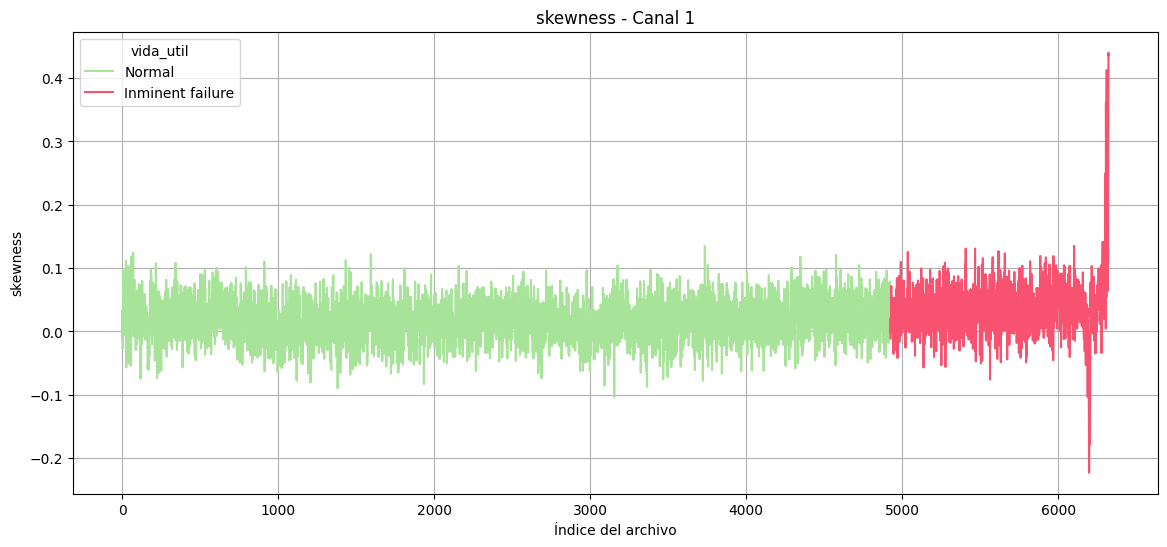

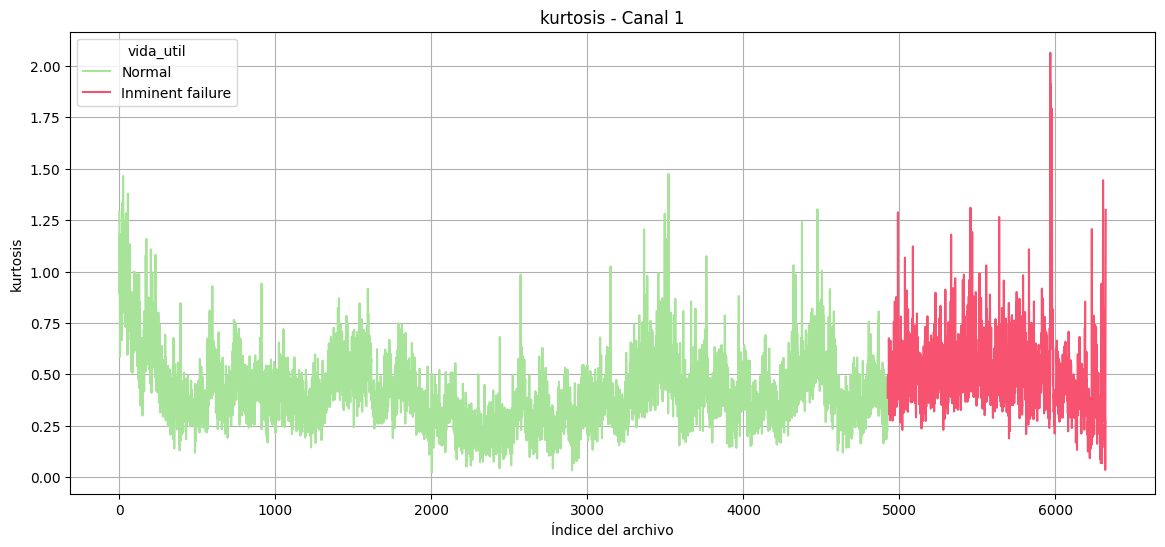

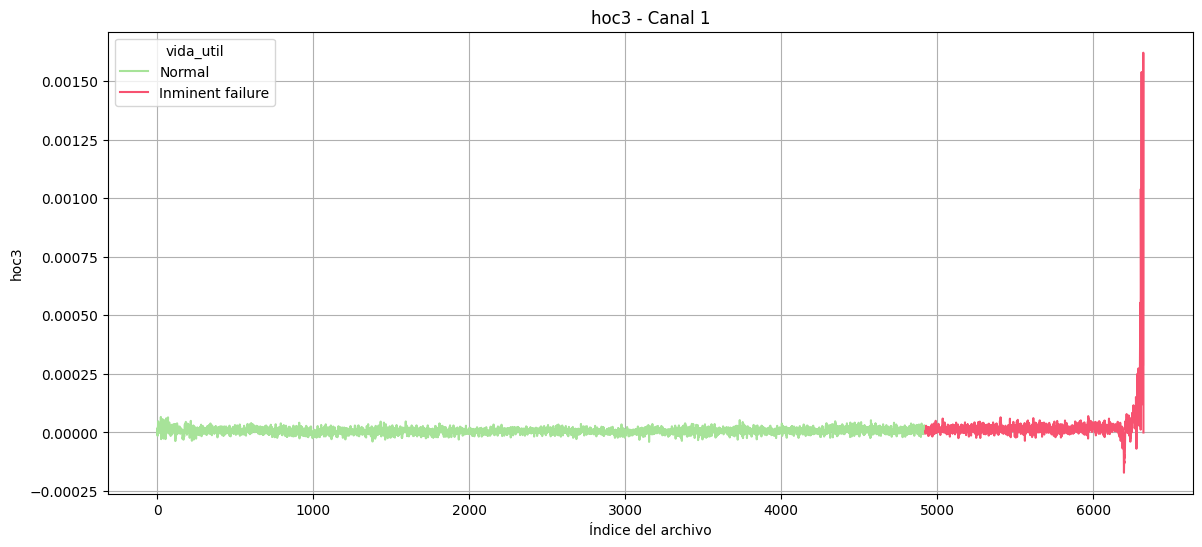

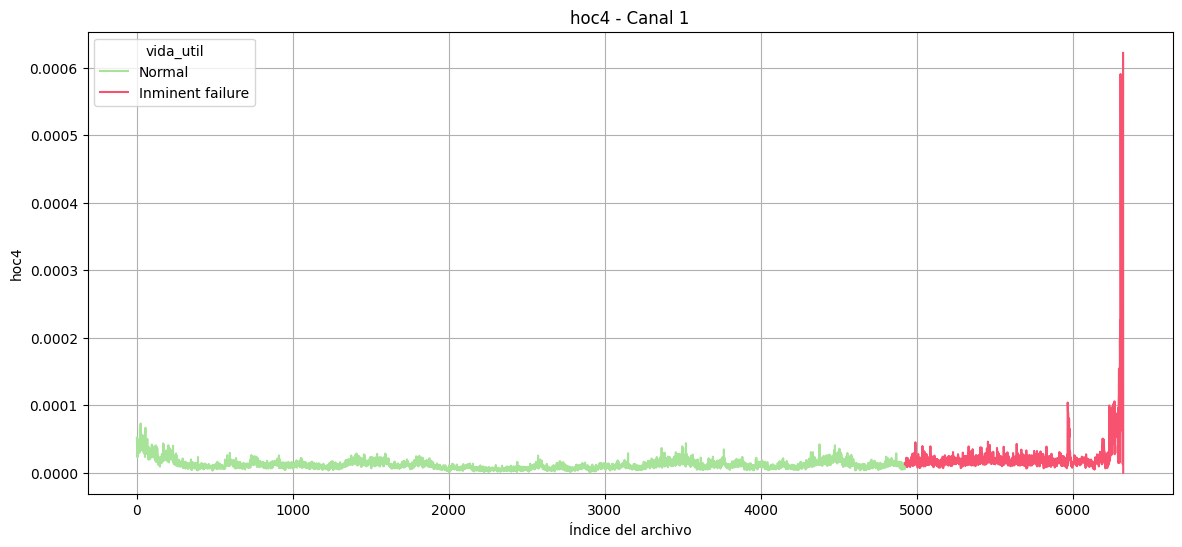

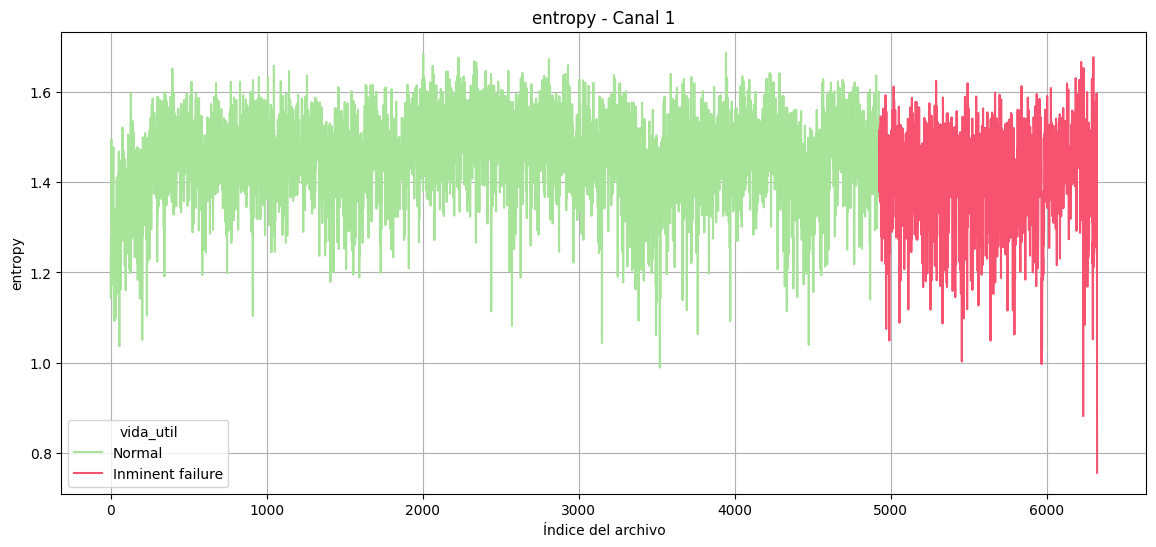

In [144]:
for i in range(len(estadisticas_a_graficar)):
    estadistica = estadisticas_a_graficar[i]
    mostrar_grafica_target(df_agregado_3rd_test, canal_a_ver, estadistica, 'vida_util', colores_salud_hex)


**Análisis**


Se puede sobservar que tambien se preserva la tendecia de los datos crudos en estas gráficas con estadísticos.

Una cosa a notar es que en los estadísticos peak_amplitude, rms_amplitude, peak_to_peak_amplitude, crest_factor, variance, standard_deviation, standard_error, zero_crossings, Willison_amplitude, impulse_factor y margin_factor se puede evidenciar la presencia de una serie de tiempo con valores muy bajos con respecto a los demás. Esta serie de tiempo corresponde a las señales cuadradas encontradas en las primeras etapas de la exploración de datos. Con esto se evidencia que la búsqueda de las señales cuadradas a los largo de los experimentos tuvo resultados afirmativos concluyendo que estas sólo estaban presenten al final de los experimentos. 